<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 1: 데이터 분석**

## **미션 설명**

- 이번 단계에서는 다음과 같이 5개의 미션을 수행합니다.

### 미션 1: 기본 탐색 및 전처리

- 분석 대상 데이터를 읽어와 기본적인 탐색을 수행합니다.
- 결측치 존재 여부를 확인하고 적절한 방법으로 처리합니다.
- Target 값을 숫자로 변경합니다.
- 분석에 불필요한 변수를 제거합니다.

### 미션 2: 가설 수립과 검증

- 탐색 과정을 통해 얻은 정보로 가설을 수립합니다.
- 데이터 시각화 분석을 통해 수립한 가설을 검증합니다.
- 모든 분석 과정에 대한 의견을 정리합니다.
- 정리된 의견은 팀 프로젝트 수행 시 발표 자료에 정리합니다.


### 미션 3: 머신러닝 모델링 #1

- 머신러닝 모델을 만들어 성능을 평가합니다.
- 변수 중요도를 확인하고 의견으로 정리합니다.

### 미션 4: 머신러닝 모델링 #2

- 데이터를 두 개로 분리합니다.
- 각각의 데이터에 대해 별도의 모델을 만들어 성능을 평가합니다.
- 각각의 모델이 중요하다고 판단한 변수를 확인하고 정리합니다.

### 미션 5: 데이터 분석

- 모델링 과정을 통해 얻은 통찰력으로 분석 대상 변수를 선택합니다.
- 선택한 변수에 대한 분석을 수행하고 결과를 의견으로 정리합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 구글 드라이브에 **project01** 폴더를 만들고 배포한 파일을 업로드합니다.
- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [108]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/KT-A/1-Data/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [109]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr
import statsmodels.api as sm
from statsmodels.genmod import families


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 데이터 불러오기

- 다음 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'survey.csv' → data

In [110]:
# 파일 읽어오기
file = path + 'survey.csv'
data = pd.read_csv(file)

In [111]:
# 데이터 읽어오기
data.head(5)

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80396,16087,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,...,5,4,2,2,3,1,5,0,0.0,Satisfied
1,20716,125832,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,...,4,4,4,4,5,4,5,10,3.0,Satisfied
2,29653,40743,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,...,4,4,4,4,2,4,4,21,7.0,Satisfied
3,94582,46572,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,...,3,2,5,5,5,4,5,142,158.0,Satisfied
4,17127,32593,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,...,3,3,4,1,1,2,3,0,0.0,Satisfied


### 컬럼 분석 해보자잉

- Unnamed: 0: 인덱스 고유값?
- ID: 승객 고유 ID
- Gender: 성별 (Male, Female)
- Customer Type: 고객 유형
- Age: 나이
- Type of Travel: 여행 유형
- Class: 좌석 등급 (Eco, Business, Eco Plus)
- Flight Distance: 비행 거리 - Inflight wifi service: 기내 와이파이 서비스 만족도 (0-5)
- Departure/Arrival time convenient: 출발/도착 시간 편리성 만족도 (0-5)
- Ease of Online booking: 온라인 예약 만족도 (0-5)
- Gate location: 탑승구 위치 편리성 만족도 (0-5)
- Food and drink: 음식 및 음료 만족도 (0-5)
- Online boarding: 온라인 탑승 수속 만족도 (0-5)
- Seat comfort: 좌석 편안함 만족도 (0-5)
- Inflight entertainment: 기내 엔터테인먼트 만족도 (0-5)
- On-board service: 기내 서비스 만족도 (0-5)
- Leg room service: 다리 공간 서비스 만족도 (0-5)
- Baggage handling: 수하물 처리 만족도 (0-5)
- Checkin service: 체크인 서비스 만족도 (0-5)
- Inflight service: 기내 서비스 만족도 (0-5)
- Cleanliness: 청결도 만족도 (0-5)
- Departure Delay in Minutes: 출발 지연 시간 (분)
- Arrival Delay in Minutes: 도착 지연 시간 (분)
- Satisfaction: 고객 만족도 (Satisfied: 만족, Neutral or Dissatisfied: 불만족 또는 보통)

## **2. 미션 1: 기본 탐색 및 전처리**

### (1) 기본정보 확인

- 데이터 형태, 기초통계량 등을 확인합니다.

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         19278 non-null  int64  
 1   ID                                 19278 non-null  int64  
 2   Gender                             19278 non-null  object 
 3   Customer Type                      19278 non-null  object 
 4   Age                                18626 non-null  float64
 5   Type of Travel                     19278 non-null  object 
 6   Class                              19278 non-null  object 
 7   Flight Distance                    19278 non-null  int64  
 8   Inflight wifi service              18640 non-null  float64
 9   Departure/Arrival time convenient  19278 non-null  int64  
 10  Ease of Online booking             19278 non-null  int64  
 11  Gate location                      19278 non-null  int

In [113]:
data.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,19278.000000,19278.000000,18626.000000,19278.000000,18640.000000,19278.000000,19278.000000,19278.000000,18893.000000,19278.000000,18791.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19224.000000
mean,51926.605716,65515.708580,41.424783,1474.563544,3.094528,2.985631,2.989159,2.989003,3.451596,3.887955,3.876111,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.833645
std,30134.716545,37481.228258,13.166125,1117.574556,1.541379,1.542553,1.540798,1.353441,1.260715,1.251155,1.193953,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.531938
min,13.000000,4.000000,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000
25%,25716.500000,33204.750000,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000
50%,51992.500000,65640.500000,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000
75%,78115.250000,97865.250000,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000
max,103901.000000,129867.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000


In [114]:
data.shape

(19278, 25)

### (2) Target 변수 확인

- Target인 **Satisfaction** 변수에 대해 단변량 분석을 수행합니다.

In [115]:
A = data['Satisfaction']

print(A)
print(A.info())
print(A.describe())
print(A.isnull().sum())

0        Satisfied
1        Satisfied
2        Satisfied
3        Satisfied
4        Satisfied
           ...    
19273    Satisfied
19274    Satisfied
19275    Satisfied
19276    Satisfied
19277    Satisfied
Name: Satisfaction, Length: 19278, dtype: object
<class 'pandas.core.series.Series'>
RangeIndex: 19278 entries, 0 to 19277
Series name: Satisfaction
Non-Null Count  Dtype 
--------------  ----- 
19278 non-null  object
dtypes: object(1)
memory usage: 150.7+ KB
None
count         19278
unique            2
top       Satisfied
freq          17293
Name: Satisfaction, dtype: object
0


### (3) 결측치 확인

- 결측치 비율을 기준으로 내림차순 정렬해 확인합니다.

In [116]:
data.isnull().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,652
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,638
Departure/Arrival time convenient,0


### (4) 결측치 채우기

- 결측치가 있는 수치형 변수는 **중앙값**으로, 범주형 변수는 **최빈값**으로 채웁니다.
    - 수치형 변수: 'Age', 'Arrival Delay in Minutes'
    - 범주형 변수: 'Inflight wifi service', 'Seat comfort', 'Food and drink'
- 추천: 이후 확장성을 위해 범주형/수치형 변수를 자동 선택하고, 결측치를 일괄 처리합니다.

In [117]:
# 수치형 변수 선택 (명시된 변수 사용)
num_col = ['Age', 'Arrival Delay in Minutes']

data[num_col] = data[num_col].fillna(data[num_col].median())


print(data[num_col].isnull().sum())

Age                         0
Arrival Delay in Minutes    0
dtype: int64


In [118]:
# 범주형 변수 선택
cate_col = ['Inflight wifi service', 'Seat comfort', 'Food and drink']

for col in cate_col:
    data[col].fillna(data[col].mode()[0], inplace=True)

print(data[cate_col].isnull().sum()) # 결측치 처리 확인

Inflight wifi service    0
Seat comfort             0
Food and drink           0
dtype: int64


### (5) Target 값 변경

- Target인 **Satisfaction** 변수  값을 1과 0으로 변경합니다.
    - 'Satisfied'--> 1,
    - 'Neutral or Dissatisfied' --> 0
- **map()** 메서드를 사용합니다.

In [119]:
# Target -> Satisfaction 값을 1과 0 바꾸자잉
data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

print(data['Satisfaction'].value_counts())

Satisfaction
1    17293
0     1985
Name: count, dtype: int64


### (6) 불필요한 변수 제거

- 다음 변수는 분석에 의미가 없으므로 제거합니다.
    - 'Unnamed: 0'
    - 'ID'

In [120]:
# 불필요한 변수 제거
data.drop(columns=['Unnamed: 0', 'ID'], axis=1, inplace=True)
print(data.columns)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'Satisfaction'],
      dtype='object')


### 위에 있던 markup 참고
### 컬럼 분석 해보자잉

- Unnamed: 0: 인덱스 고유값?
- ID: 승객 고유 ID
- Gender: 성별 (Male, Female)
- Customer Type: 고객 유형
- Age: 나이
- Type of Travel: 여행 유형
- Class: 좌석 등급 (Eco, Business, Eco Plus)
- Flight Distance: 비행 거리 - Inflight wifi service: 기내 와이파이 서비스 만족도 (0-5)
- Departure/Arrival time convenient: 출발/도착 시간 편리성 만족도 (0-5)
- Ease of Online booking: 온라인 예약 만족도 (0-5)
- Gate location: 탑승구 위치 편리성 만족도 (0-5)
- Food and drink: 음식 및 음료 만족도 (0-5)
- Online boarding: 온라인 탑승 수속 만족도 (0-5)
- Seat comfort: 좌석 편안함 만족도 (0-5)
- Inflight entertainment: 기내 엔터테인먼트 만족도 (0-5)
- On-board service: 기내 서비스 만족도 (0-5)
- Leg room service: 다리 공간 서비스 만족도 (0-5)
- Baggage handling: 수하물 처리 만족도 (0-5)
- Checkin service: 체크인 서비스 만족도 (0-5)
- Inflight service: 기내 서비스 만족도 (0-5)
- Cleanliness: 청결도 만족도 (0-5)
- Departure Delay in Minutes: 출발 지연 시간 (분)
- Arrival Delay in Minutes: 도착 지연 시간 (분)
- Satisfaction: 고객 만족도 (Satisfied: 만족, Neutral or Dissatisfied: 불만족 또는 보통)

### (1) 가설 수립

- 'ㅇㅇ이면 ㅇㅇ일 것이다' 라는 형식의 가설을 5개 이상 세워봅니다.
- 이후 분석 과정을 통해 수립한 가설을 검증합니다.
- 특히 이변량 분석을 통해 가설을 검증하도록 합니다.

In [121]:
# 가설 1: 온라인 만족도가 높다면 (5에 수렴한다면) 고객만족도 (Satisfaction)가 높을 것이다.
# 가설 2: 출발 지연 시간이 적다면(기다리는 시간이 짧다면) 고객만족도 (Satisfaction)가 높을 것이다.
# 가설 3: 좌석 등급이 (Class)가 낮다면 고객만족도 (Satisfaction)가 낮을 것이다.
# 가설 4: 좌석 편안함에 만족도가 높다면 (5에 수렴한다면) 고객만족도 (Satisfaction)가 높을 것이다.
# 가설 5: 체크인 서비스에 만족도가 높다면 (5에 수렴한다면) 고객만족도 (Satisfaction)가 높을 것이다.

### (2) 단변량 분석

- 5개 이상의 변수에 대한 단변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

In [122]:
data.head(3) #확인

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,1,1,...,5,4,2,2,3,1,5,0,0.0,1
1,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,1,1,...,4,4,4,4,5,4,5,10,3.0,1
2,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,1,1,...,4,4,4,4,2,4,4,21,7.0,1


In [123]:
data.describe() #확인 -> 시각화 준비

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
count,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000
mean,41.478058,1474.563544,3.124494,2.985631,2.989159,2.989003,3.462548,3.887955,3.879241,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.797697,0.897033
std,12.944685,1117.574556,1.524288,1.542553,1.540798,1.353441,1.250418,1.251155,1.178935,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.490208,0.303924
min,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000,1.000000
50%,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000,1.000000
75%,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000,1.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000,1.000000


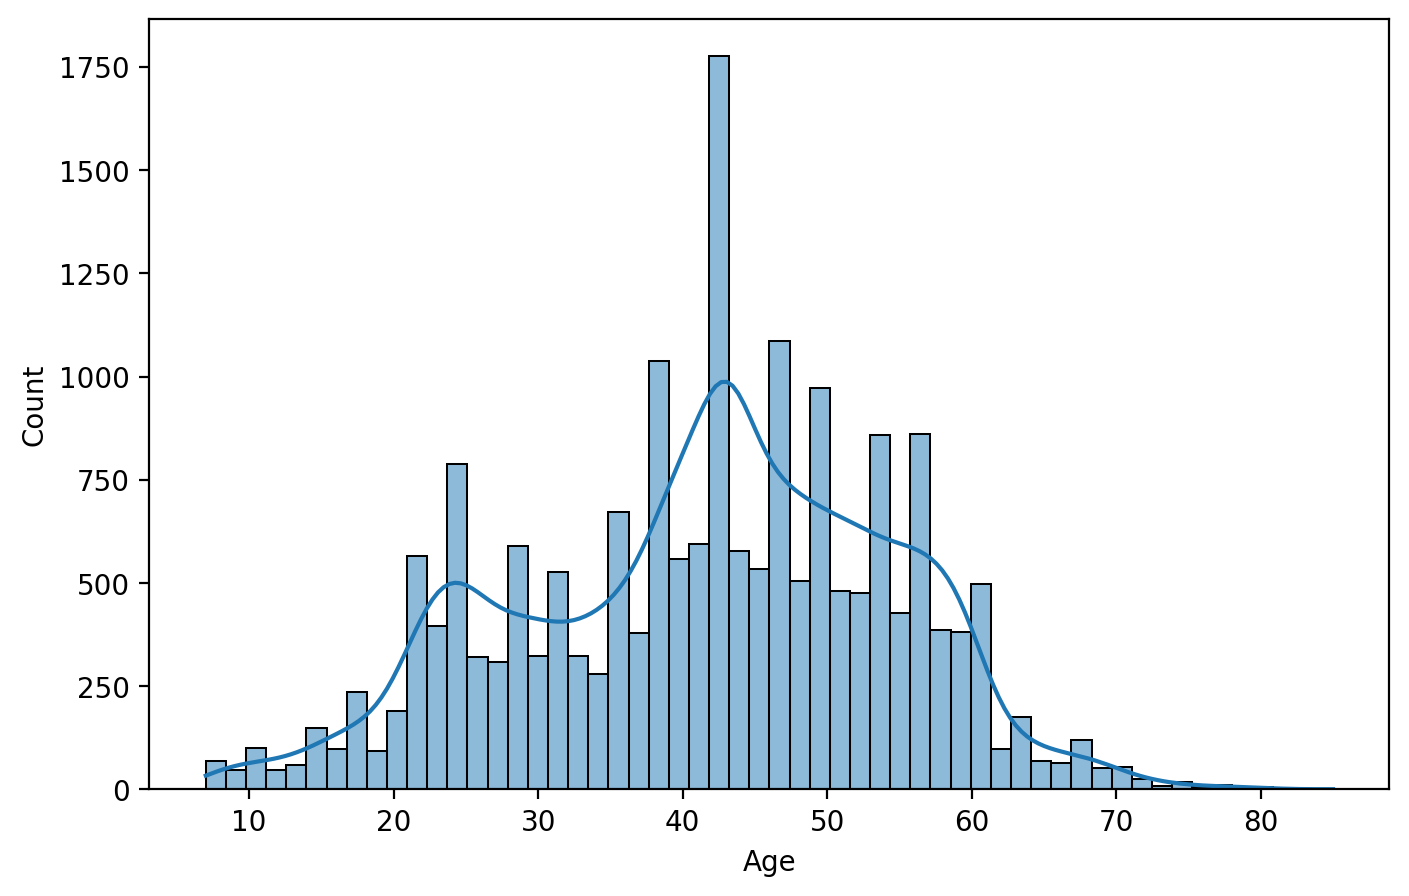

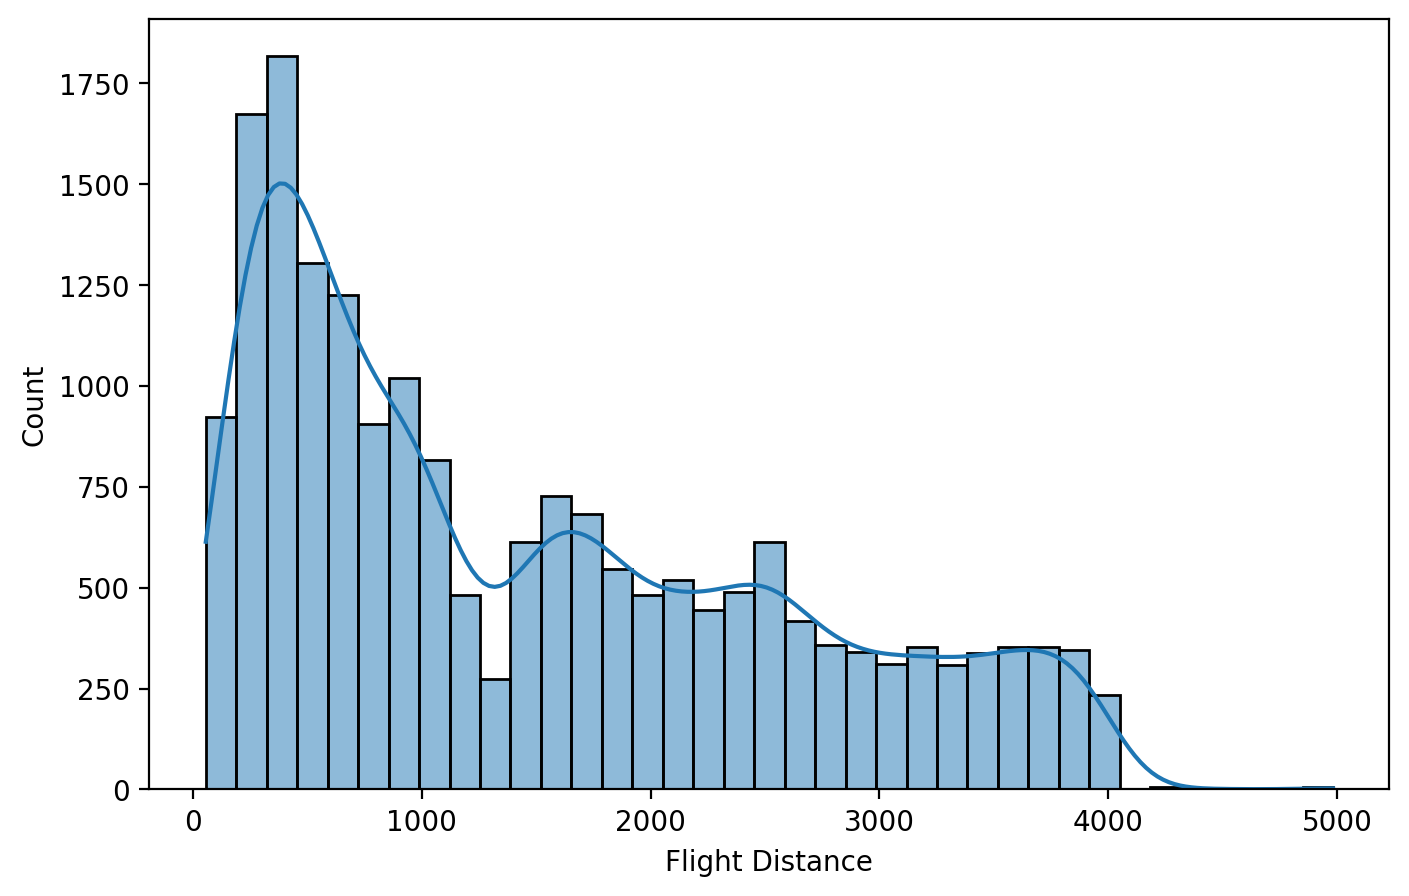

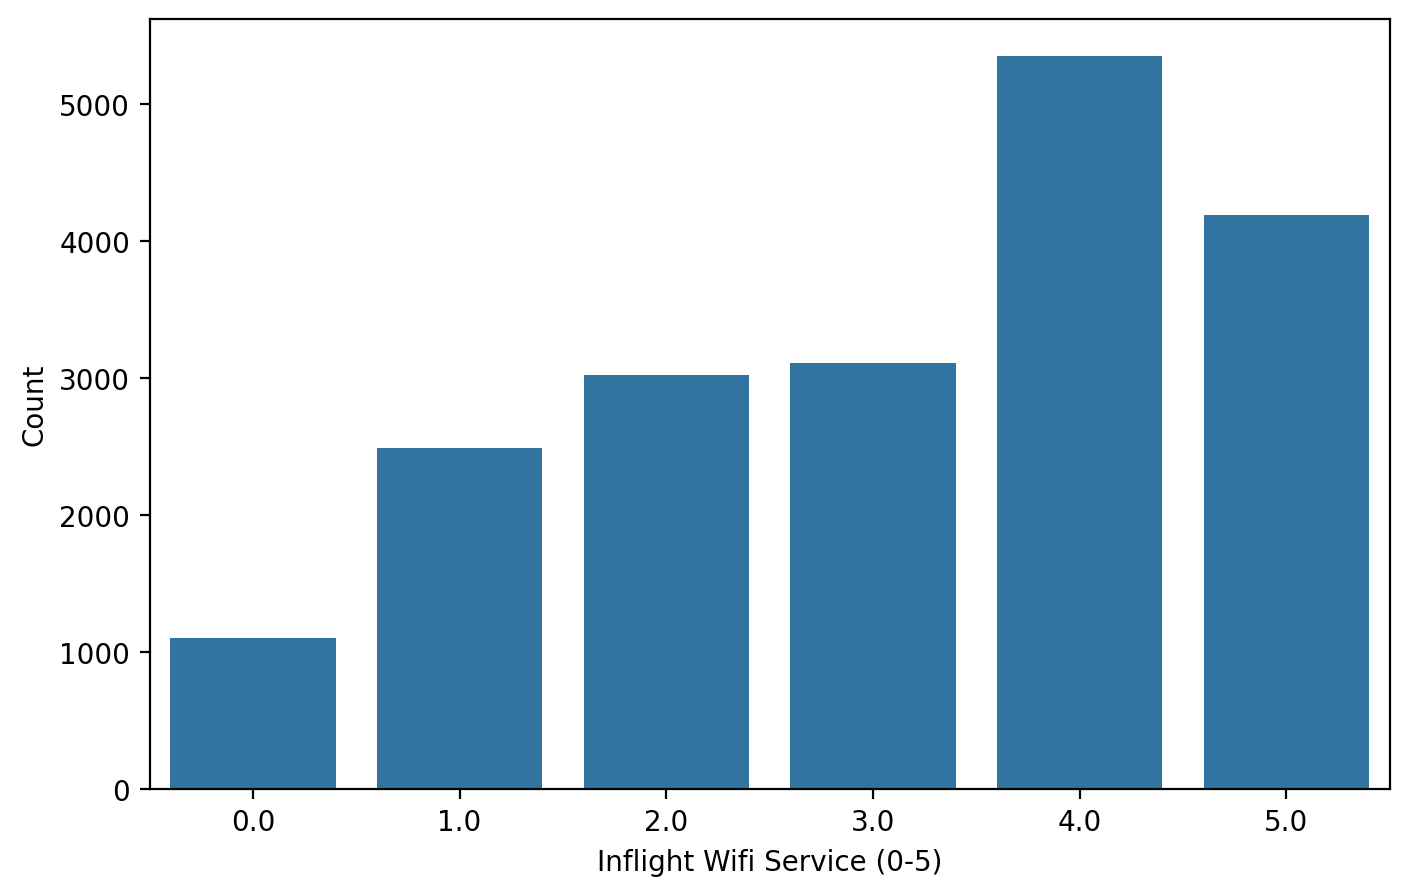

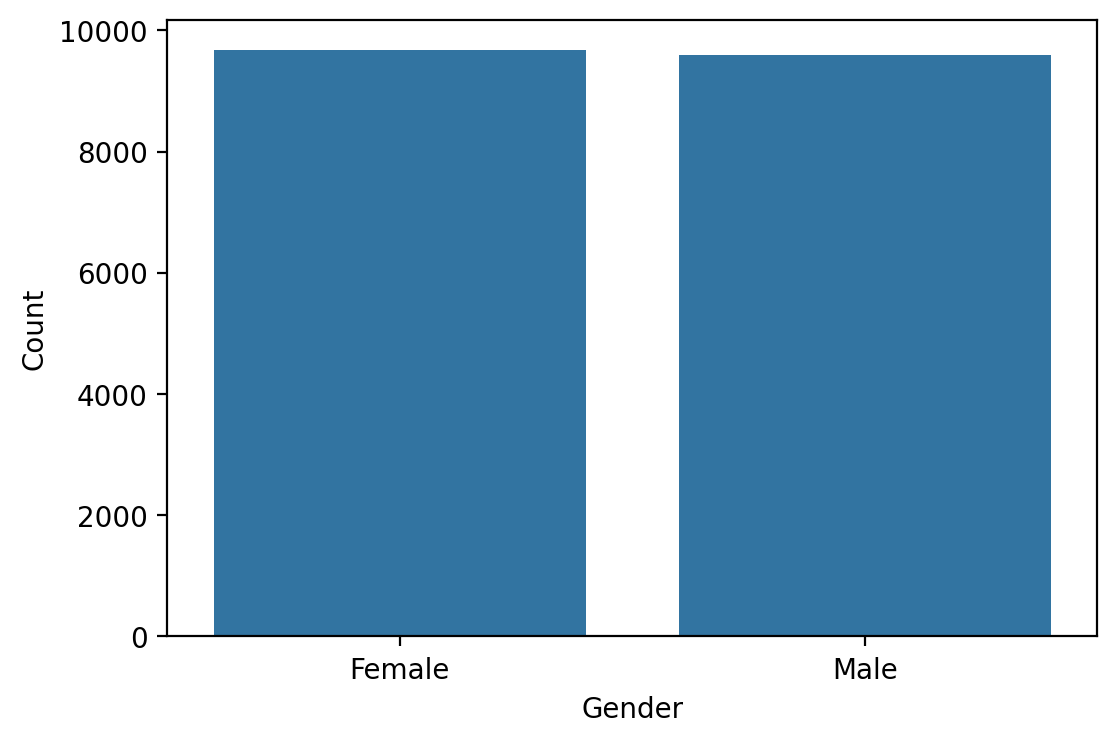

In [124]:
# 단편적으로 mean(평균값에 대해서 분석해보자이)

# data.info()
# data.describe()

# Y 값은 항상 Count로 고정!


# 'Age' 변수의 분포 확인
plt.figure(figsize=(8, 5))
sns.histplot(data['Age'], kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
# 나이 분포는 20대 후반부터 60대 초반까지 고르게 분포, 40대 후반에서 50대 초반에 가장 높음.

# 'Flight Distance' 변수의 분포 확인
plt.figure(figsize=(8, 5))
sns.histplot(data['Flight Distance'], kde=True)
plt.xlabel('Flight Distance')
plt.ylabel('Count')
plt.show()
# 의견: 비행 거리는 단거리 비행이  > 장거리 비행 -> 장기로 갈수록 수가 급격히 줄어든다.

# 'Inflight wifi service' 변수의 분포 확인
plt.figure(figsize=(8, 5))
sns.countplot(x='Inflight wifi service', data=data)
plt.xlabel('Inflight Wifi Service (0-5)')
plt.ylabel('Count')
plt.show()
# 의견: 기내 와이파이 서비스 만족도는 0점과 3점, 4점, 5점에 집중되어 있으며,

# 'Gender' 변수의 분포 확인
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=data)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.show()
# 성별은 남성, 여성 고르게 분포함

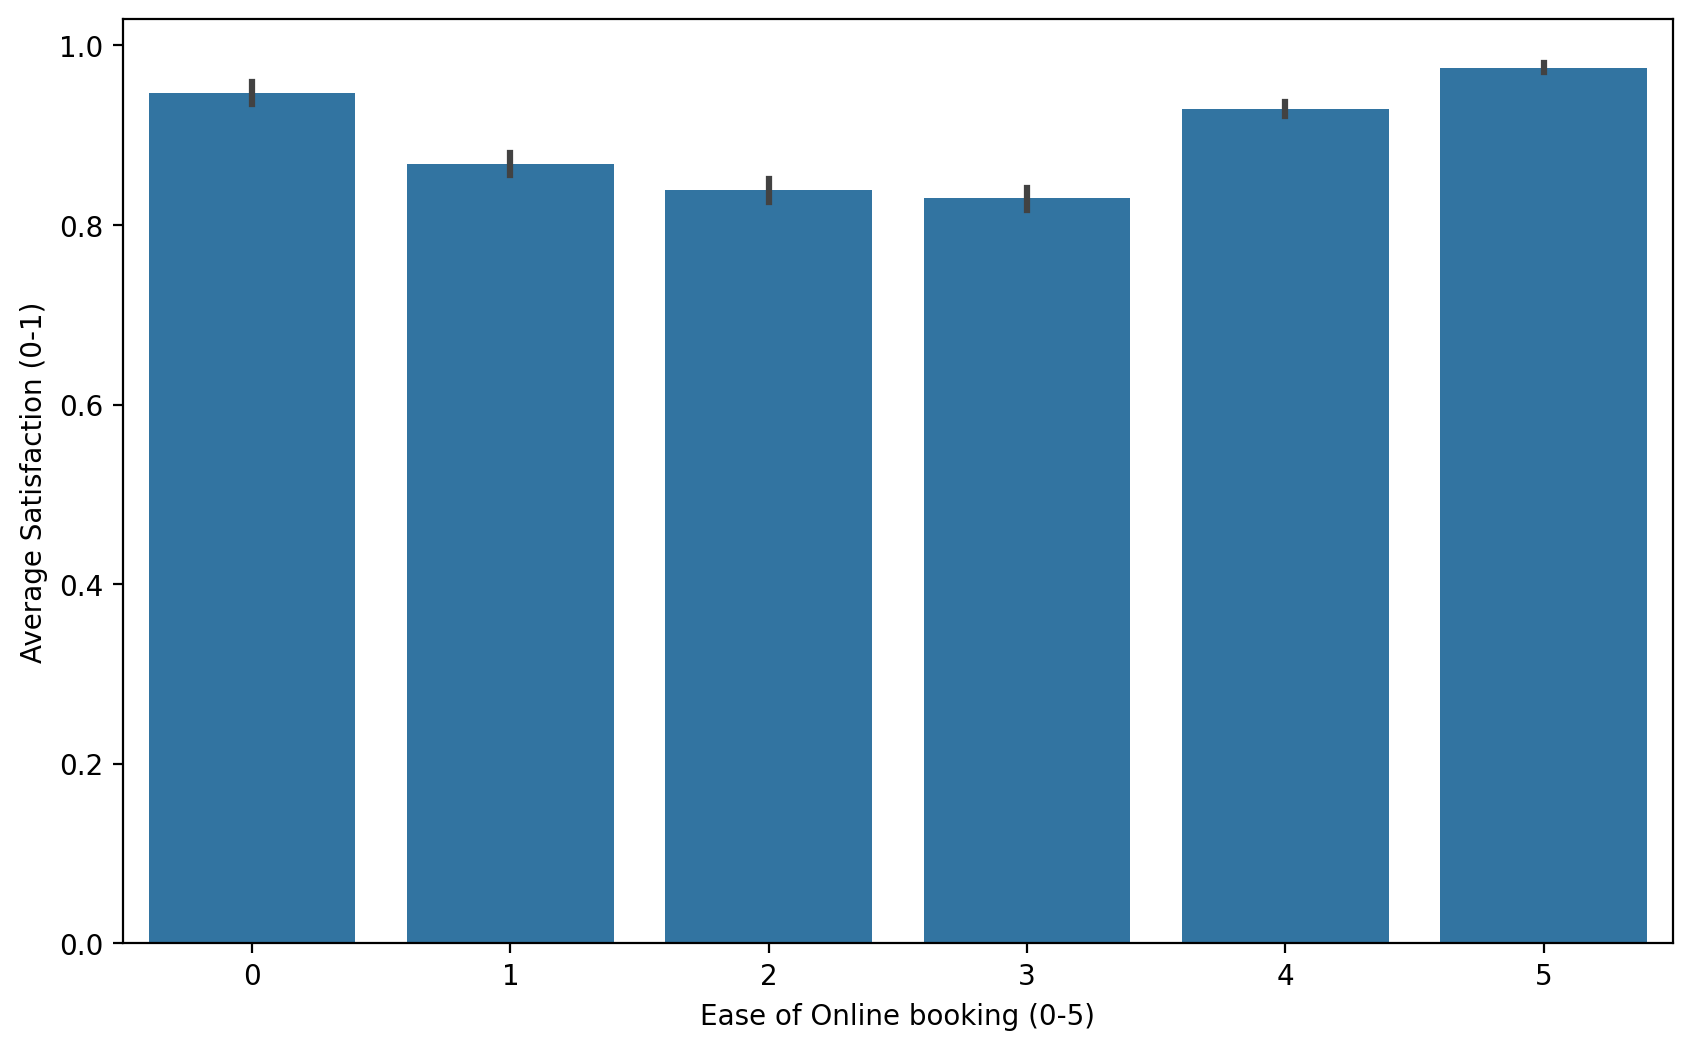

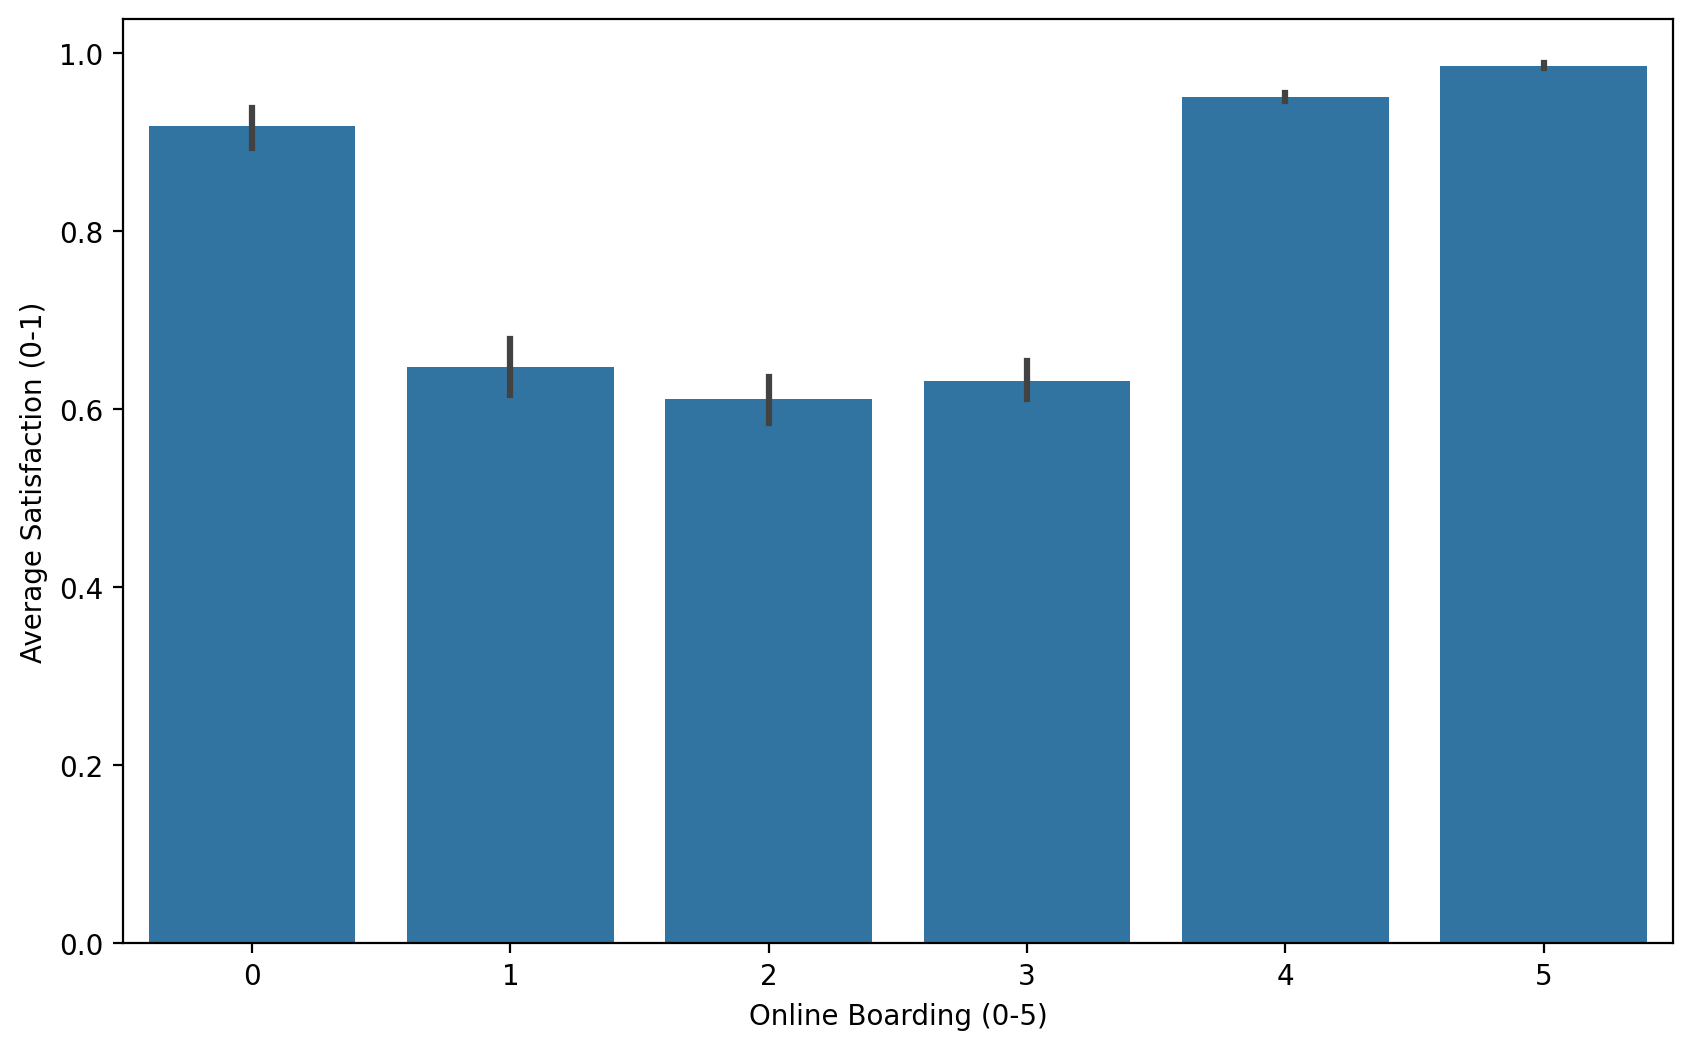

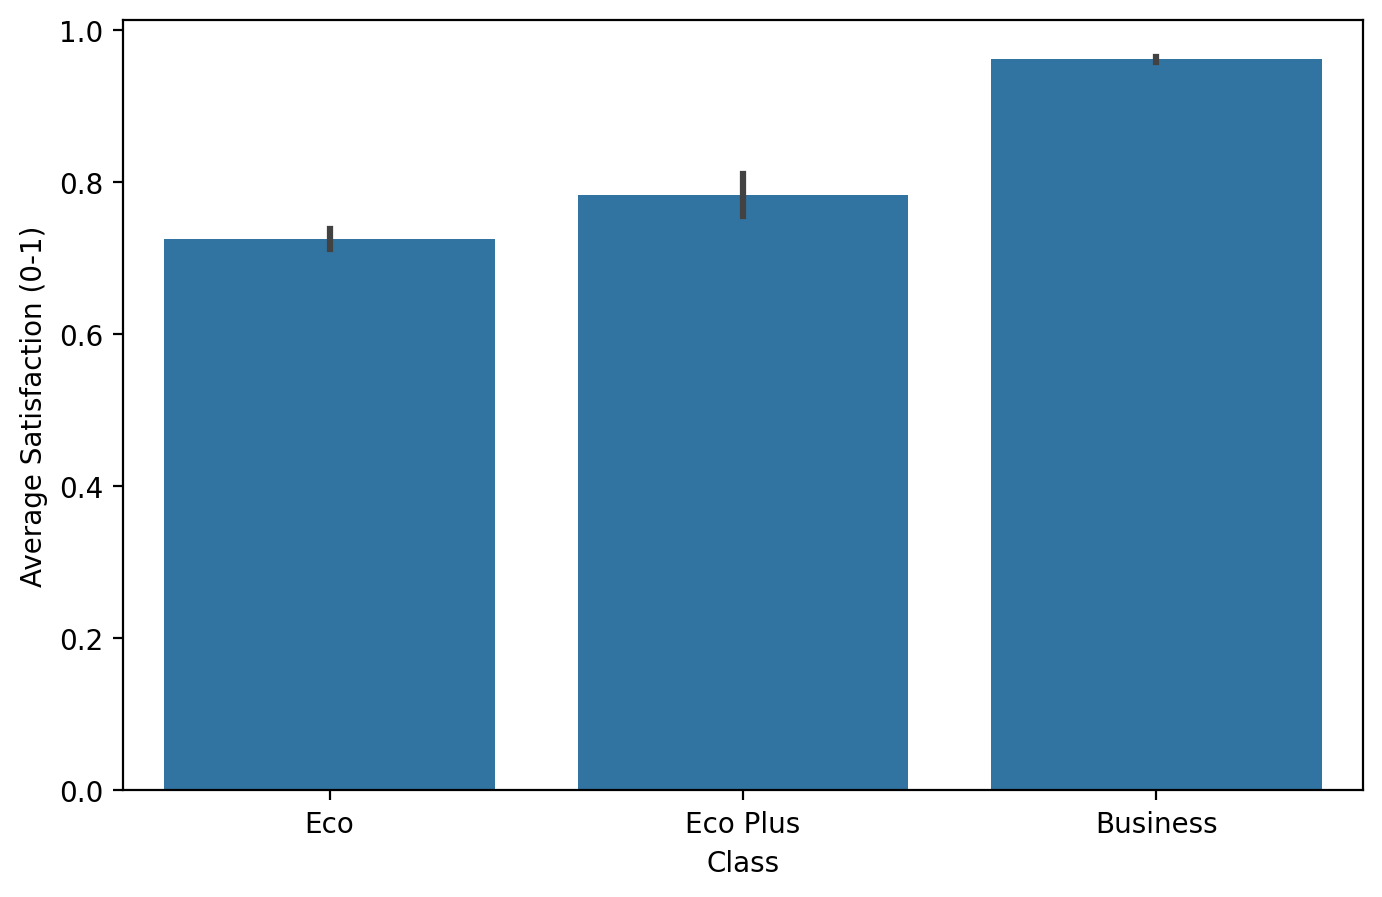

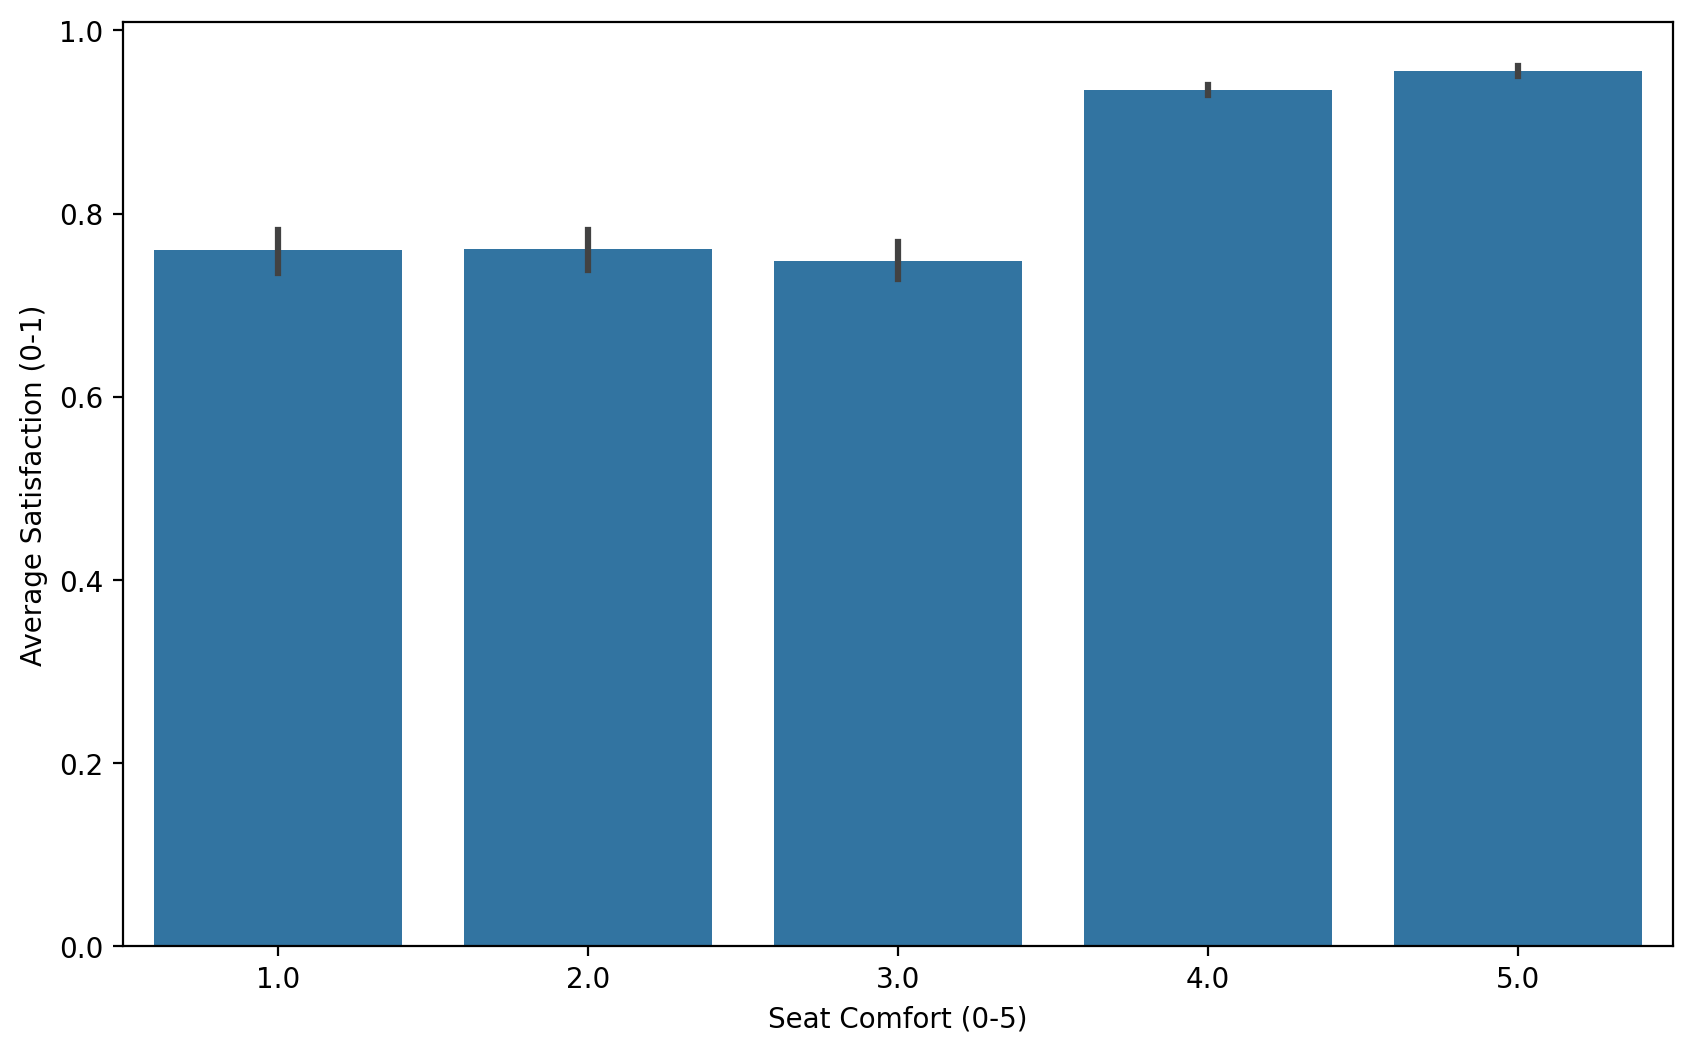

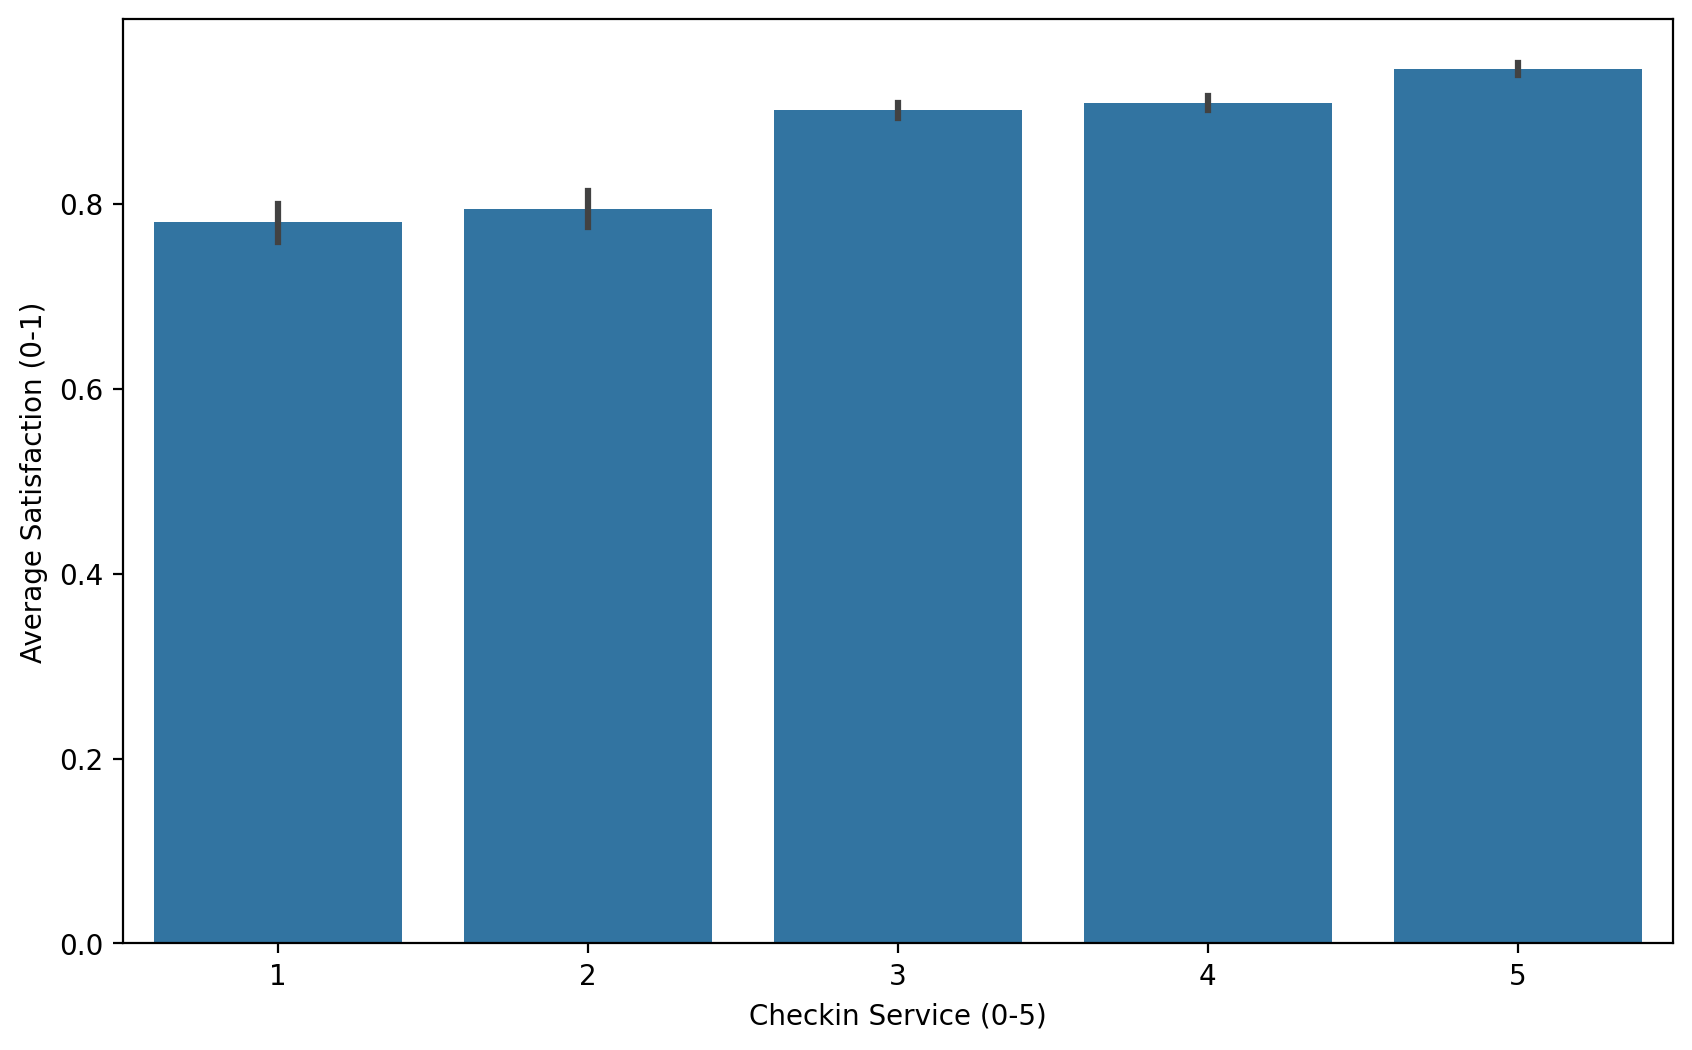

In [125]:
# Y를 만족도로 고정하자이!

# 가설 1: 온라인 만족도가 높다면 (5에 수렴한다면) 고객만족도 (Satisfaction)이 높을 것이다.
plt.figure(figsize=(10, 6))
sns.barplot(x='Ease of Online booking', y='Satisfaction', data=data)
plt.xlabel('Ease of Online booking (0-5)')
plt.ylabel('Average Satisfaction (0-1)')
plt.show()
# 온라인 예약 편리성 만족도가 높을수록 고객 만족도 또한 높다. -> 가설과 일치하지 않음 (고르게 분포)


# 가설 2 : 온라인 탑승수속에 만족도가 높다면 (5에 수렴한다면) 고객만족도 (Satisfaction)이 높을 것이다.
plt.figure(figsize=(10, 6))
sns.barplot(x='Online boarding', y='Satisfaction', data=data)
plt.xlabel('Online Boarding (0-5)')
plt.ylabel('Average Satisfaction (0-1)')
plt.show()
# 온라인 탑승 수속 만족도가 높을수록 고객 만족도도 높다 -> 가설과 일치


# 가설 3: 좌석 등급이 (Class)가 낮다면 고객만족도 (Satisfaction)이 낮을 것이다.
plt.figure(figsize=(8, 5))
sns.barplot(x='Class', y='Satisfaction', data=data, order=['Eco', 'Eco Plus', 'Business'])
plt.xlabel('Class')
plt.ylabel('Average Satisfaction (0-1)')
plt.show()
# 좌석 등급이 'Business'일 때 고객 만족도가 가장 높고, 'Eco Plus', 'Eco' 순으로 만족도가 낮아짐 ->  가설과 일치

# 가설 4: 좌석 편안함에 만족도가 높다면 (5에 수렴한다면) 고객만족도 (Satisfaction)이 높을 것이다.
plt.figure(figsize=(10, 6))
sns.barplot(x='Seat comfort', y='Satisfaction', data=data)
plt.xlabel('Seat Comfort (0-5)')
plt.ylabel('Average Satisfaction (0-1)')
plt.show()
# 좌석 편안함 만족도가 높을수록 고객 만족도도 비례 높아짐 -> 가설과 일치

# 가설 5: 체크인 서비스에 만족도가 높다면 (5에 수렴한다면) 고객만족도 (Satisfaction)이 높을 것이다.
plt.figure(figsize=(10, 6))
sns.barplot(x='Checkin service', y='Satisfaction', data=data)
plt.xlabel('Checkin Service (0-5)')
plt.ylabel('Average Satisfaction (0-1)')
plt.show()
# 체크인 만족도 점수가 높을수록 고객 만족도가 증가함 -> 가설과 일치

### (3) 이변량 분석

- 5개 이상의 이변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

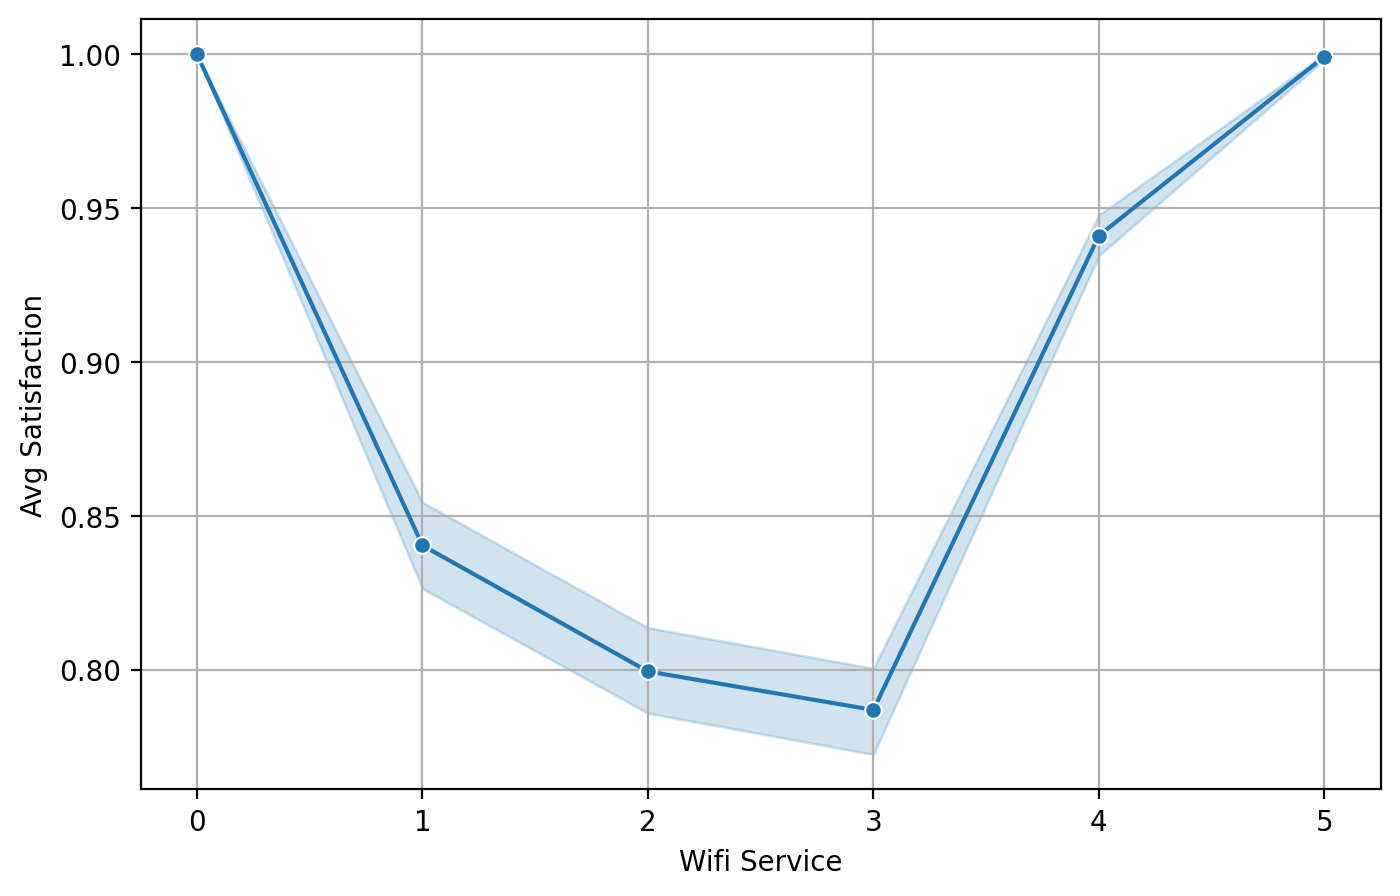

Chi2=1520.53, P-value=0.000


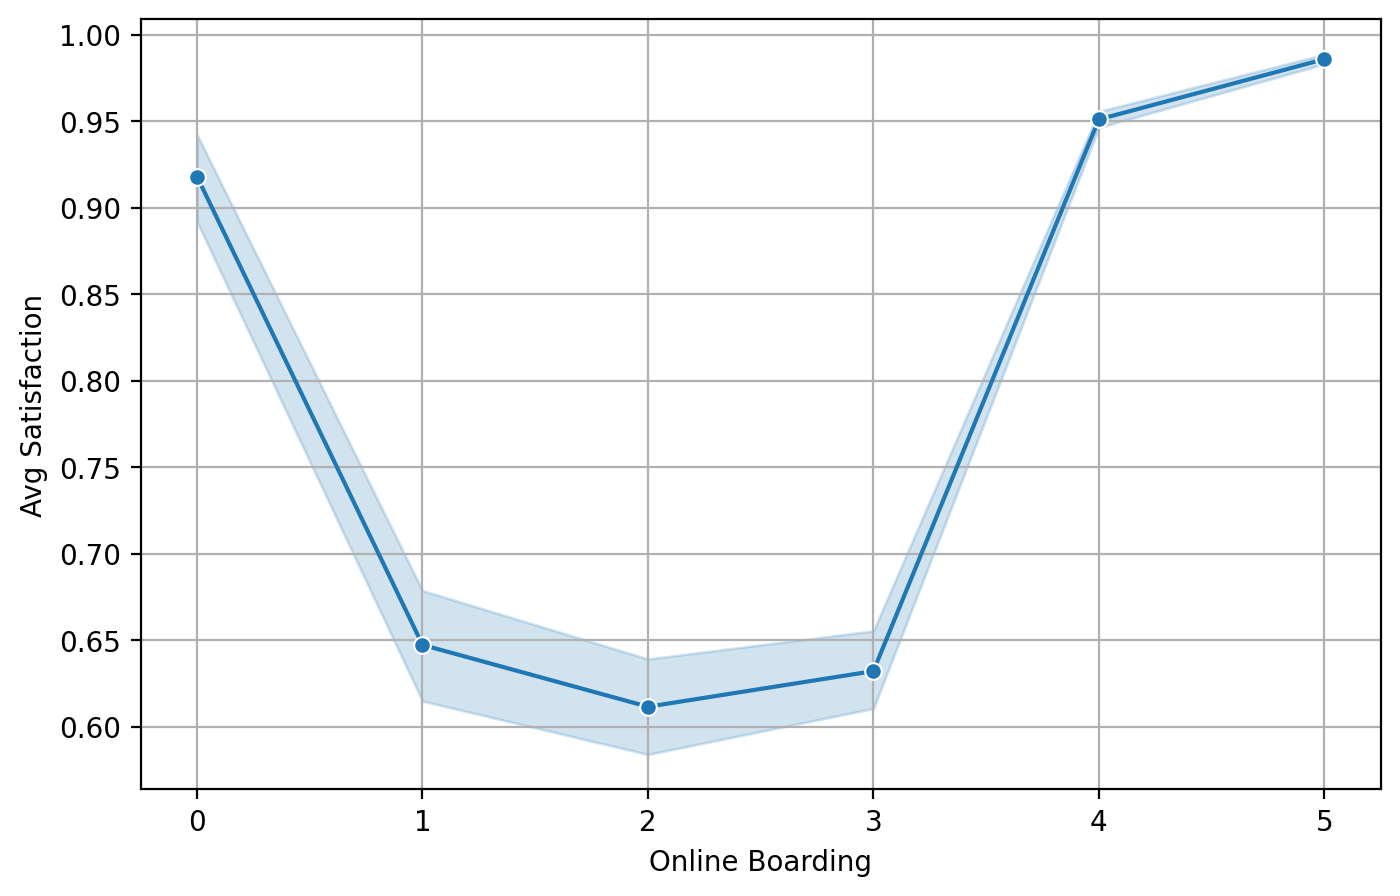

Point-biserial Corr=0.332, P-value=0.000


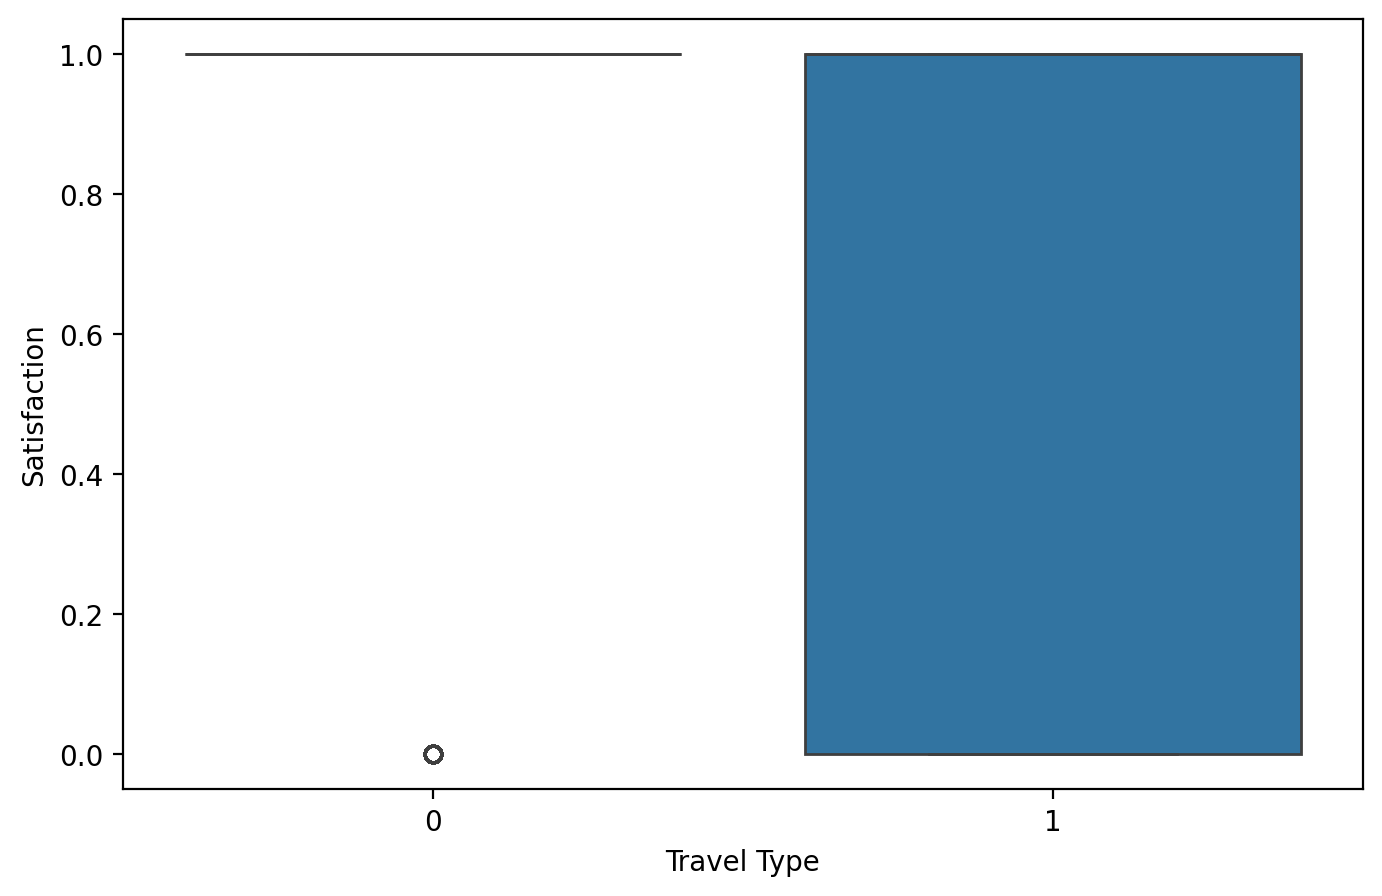

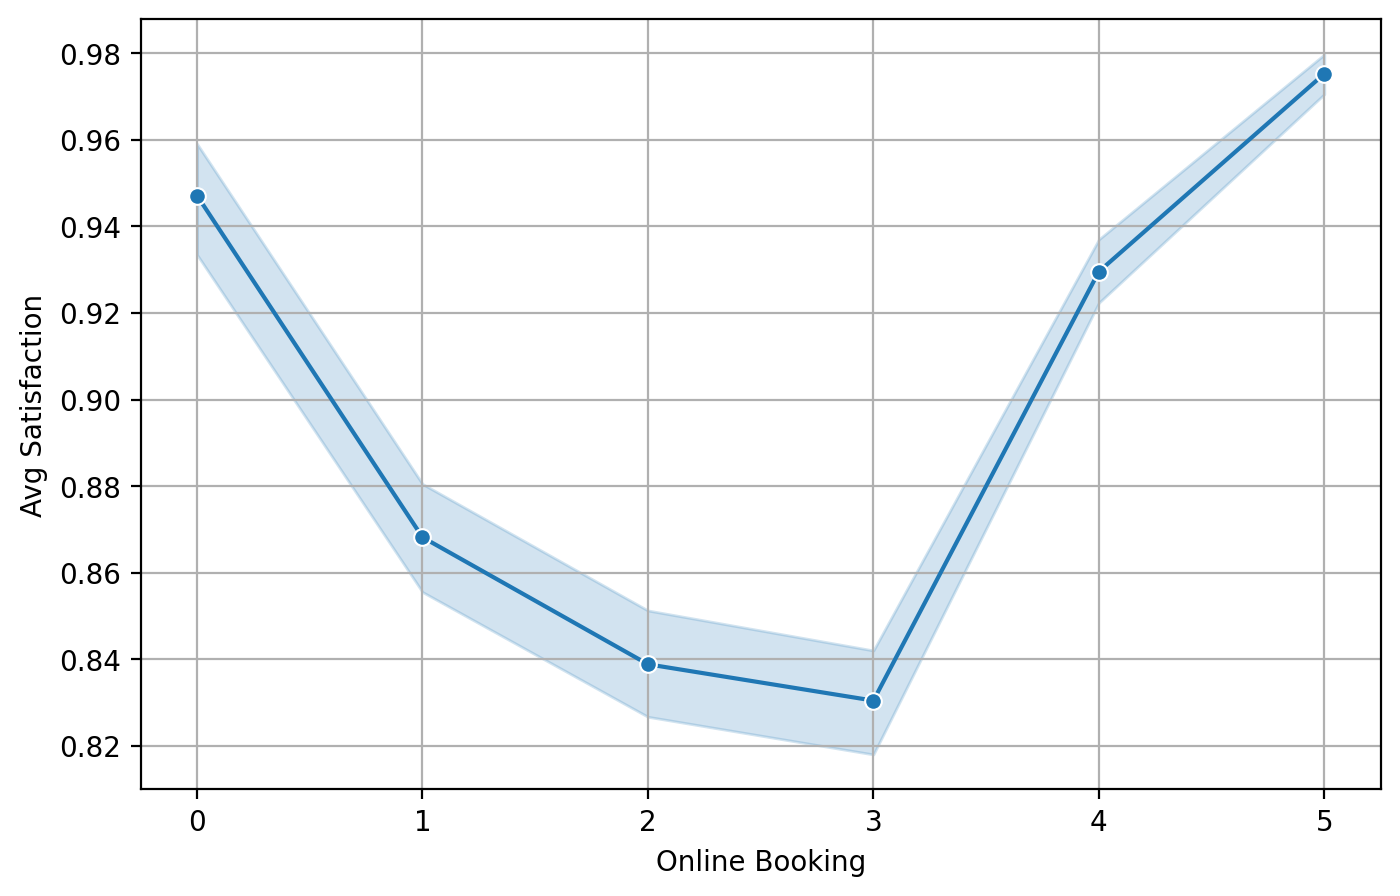

Chi2=667.89, P-value=0.000


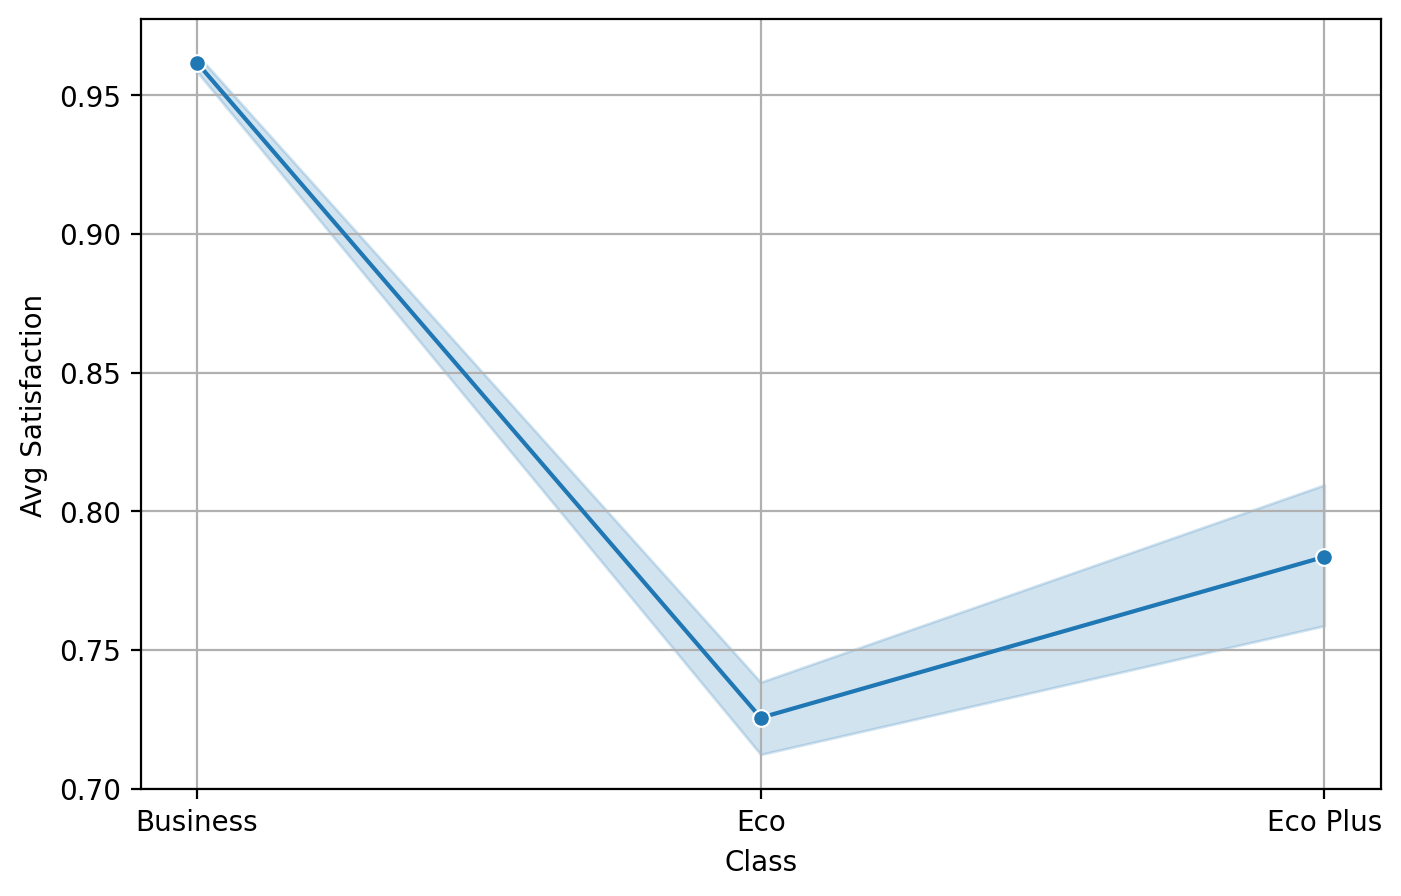

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                19278
Model:                            GLM   Df Residuals:                    19276
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5685.1
Date:                Tue, 14 Apr 2026   Deviance:                       11370.
Time:                        05:43:30   Pearson chi2:                 1.73e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07068
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8634      0.035     80.994      0.0

In [162]:
# 1. 와이파이서비스 vs 만족도
plt.figure(figsize=(8, 5))
sns.lineplot(x='Inflight wifi service', y='Satisfaction', data=data, marker='o')
plt.xlabel('Wifi Service')
plt.ylabel('Avg Satisfaction')
plt.xticks(range(6))
plt.grid(True)
plt.show()
contingency_table_wifi = pd.crosstab(data['Inflight wifi service'], data['Satisfaction'])
chi2_wifi, p_val_wifi, dof_wifi, expected_wifi = chi2_contingency(contingency_table_wifi)
print(f"Chi2={chi2_wifi:.2f}, P-value={p_val_wifi:.3f}")

# 2. 온라인 탑승 수속 vs 만족도
plt.figure(figsize=(8, 5))
sns.lineplot(x='Online boarding', y='Satisfaction', data=data, marker='o')
plt.xlabel('Online Boarding')
plt.ylabel('Avg Satisfaction')
plt.xticks(range(6))
plt.grid(True)
plt.show()
correlation_online, p_val_online = pointbiserialr(data['Online boarding'], data['Satisfaction'])
print(f"Point-biserial Corr={correlation_online:.3f}, P-value={p_val_online:.3f}")


# 3.여행유형 vs 만족도
plt.figure(figsize=(8, 5))
sns.boxplot(x='Type of Travel', y='Satisfaction', data=data)
plt.xlabel('Travel Type')
plt.ylabel('Satisfaction')
plt.show()

business_travel_satisfaction = data[data['Type of Travel'] == 0]['Satisfaction']
personal_travel_satisfaction = data[data['Type of Travel'] == 1]['Satisfaction']

# 4. 온라인 예약 만족도 vs 만족도
plt.figure(figsize=(8, 5))
sns.lineplot(x='Ease of Online booking', y='Satisfaction', data=data, marker='o')
plt.xlabel('Online Booking')
plt.ylabel('Avg Satisfaction')
plt.xticks(range(6))
plt.grid(True)
plt.show()
contingency_table_booking = pd.crosstab(data['Ease of Online booking'], data['Satisfaction'])
chi2_booking, p_val_booking, dof_booking, expected_booking = chi2_contingency(contingency_table_booking)
print(f"Chi2={chi2_booking:.2f}, P-value={p_val_booking:.3f}")


# 5. 좌석등급 vs 만족도
plt.figure(figsize=(8, 5))
sns.lineplot(x='Class', y='Satisfaction', data=data, marker='o')
plt.xlabel('Class')
plt.ylabel('Avg Satisfaction')
plt.xticks(ticks=[0, 1, 2], labels=['Business', 'Eco', 'Eco Plus']) # 레이블이랑 매칭
plt.grid(True)
plt.show()


if data['Class'].dtype == 'object':
    print("Warning: data['Class'] is object dtype. Re-applying LabelEncoder for 'Class'.")
    encoder = LabelEncoder()
    data['Class'] = encoder.fit_transform(data['Class'])

X_class_np = sm.add_constant(data['Class'].astype(float)).values
y_class_np = data['Satisfaction'].values

logit_model_class = sm.GLM(y_class_np, X_class_np, family=families.Binomial()).fit()
print(logit_model_class.summary())

## **4. 미션 3: 머신러닝 모델링 #1**

- Tree 기반 알고리즘을 사용해야 **변수 중요도**를 확인할 수 있습니다.
- **RandomForest** 알고리즘을 사용해 머신러닝 모델을 만들고 성능을 평가합니다.
- **변수 중요도**를 확인해 추가 분석 대상 변수를 선정합니다.

### (1) 전처리

- 최소한 문자열 데이터가 없어야 하고, 결측치도 없도록 전처리해야 합니다.
- 결측치는 이전 단계에서 처리한 상태입니다.
- 범주형 변수에 대해 **LabelEncoder**를 사용해 인코딩합니다.
- 변수 중요도를 확인하기 위함이므로 가변수화를 하지 않습니다.

In [127]:
# 변수 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  object 
 1   Customer Type                      19278 non-null  object 
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  object 
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

In [128]:
# 문자열 변수 리스트로 선언
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# 라벨 인코딩
for col in cat_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])

display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

None

- info() 메서드로 변수 정보를 다시 확인합니다.
- **Dtype에 object 형식의 열이 있으면 이후 과정을 진행할 수 없습니다.**

In [129]:
# 인코딩 확인
data.info() # object 사라짐

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

- target 변수를 선정하고 x, y를 분리합니다.

In [130]:
# 타겟 지정
target = 'Satisfaction'

# 데이터 분리
x = data.drop(target, axis=1)
y = data[target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [131]:
# 라이브러리 생략 (위에서 선언함)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=1)

### (2) 모델링

- 머신러닝 모델링을 수행합니다.
- 검증 데이터로 예측하고 성능을 평가해 봅니다.

In [132]:
# x 행열 확인 다시
x.shape

(19278, 22)

In [133]:
# RandomForestClassifier 모델 생성 및 학습 -> 모든 모델 동일한 모델 사용 예정
model = RandomForestClassifier(random_state=1)
model.fit(x_train, y_train)

# 예측 및 성능 평가
y_pred = model.predict(x_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84       581
           1       0.98      0.99      0.98      5203

    accuracy                           0.97      5784
   macro avg       0.94      0.89      0.91      5784
weighted avg       0.97      0.97      0.97      5784



### (3) 변수 중요도 확인

- 변수 중요도를 시각화해 확인합니다.

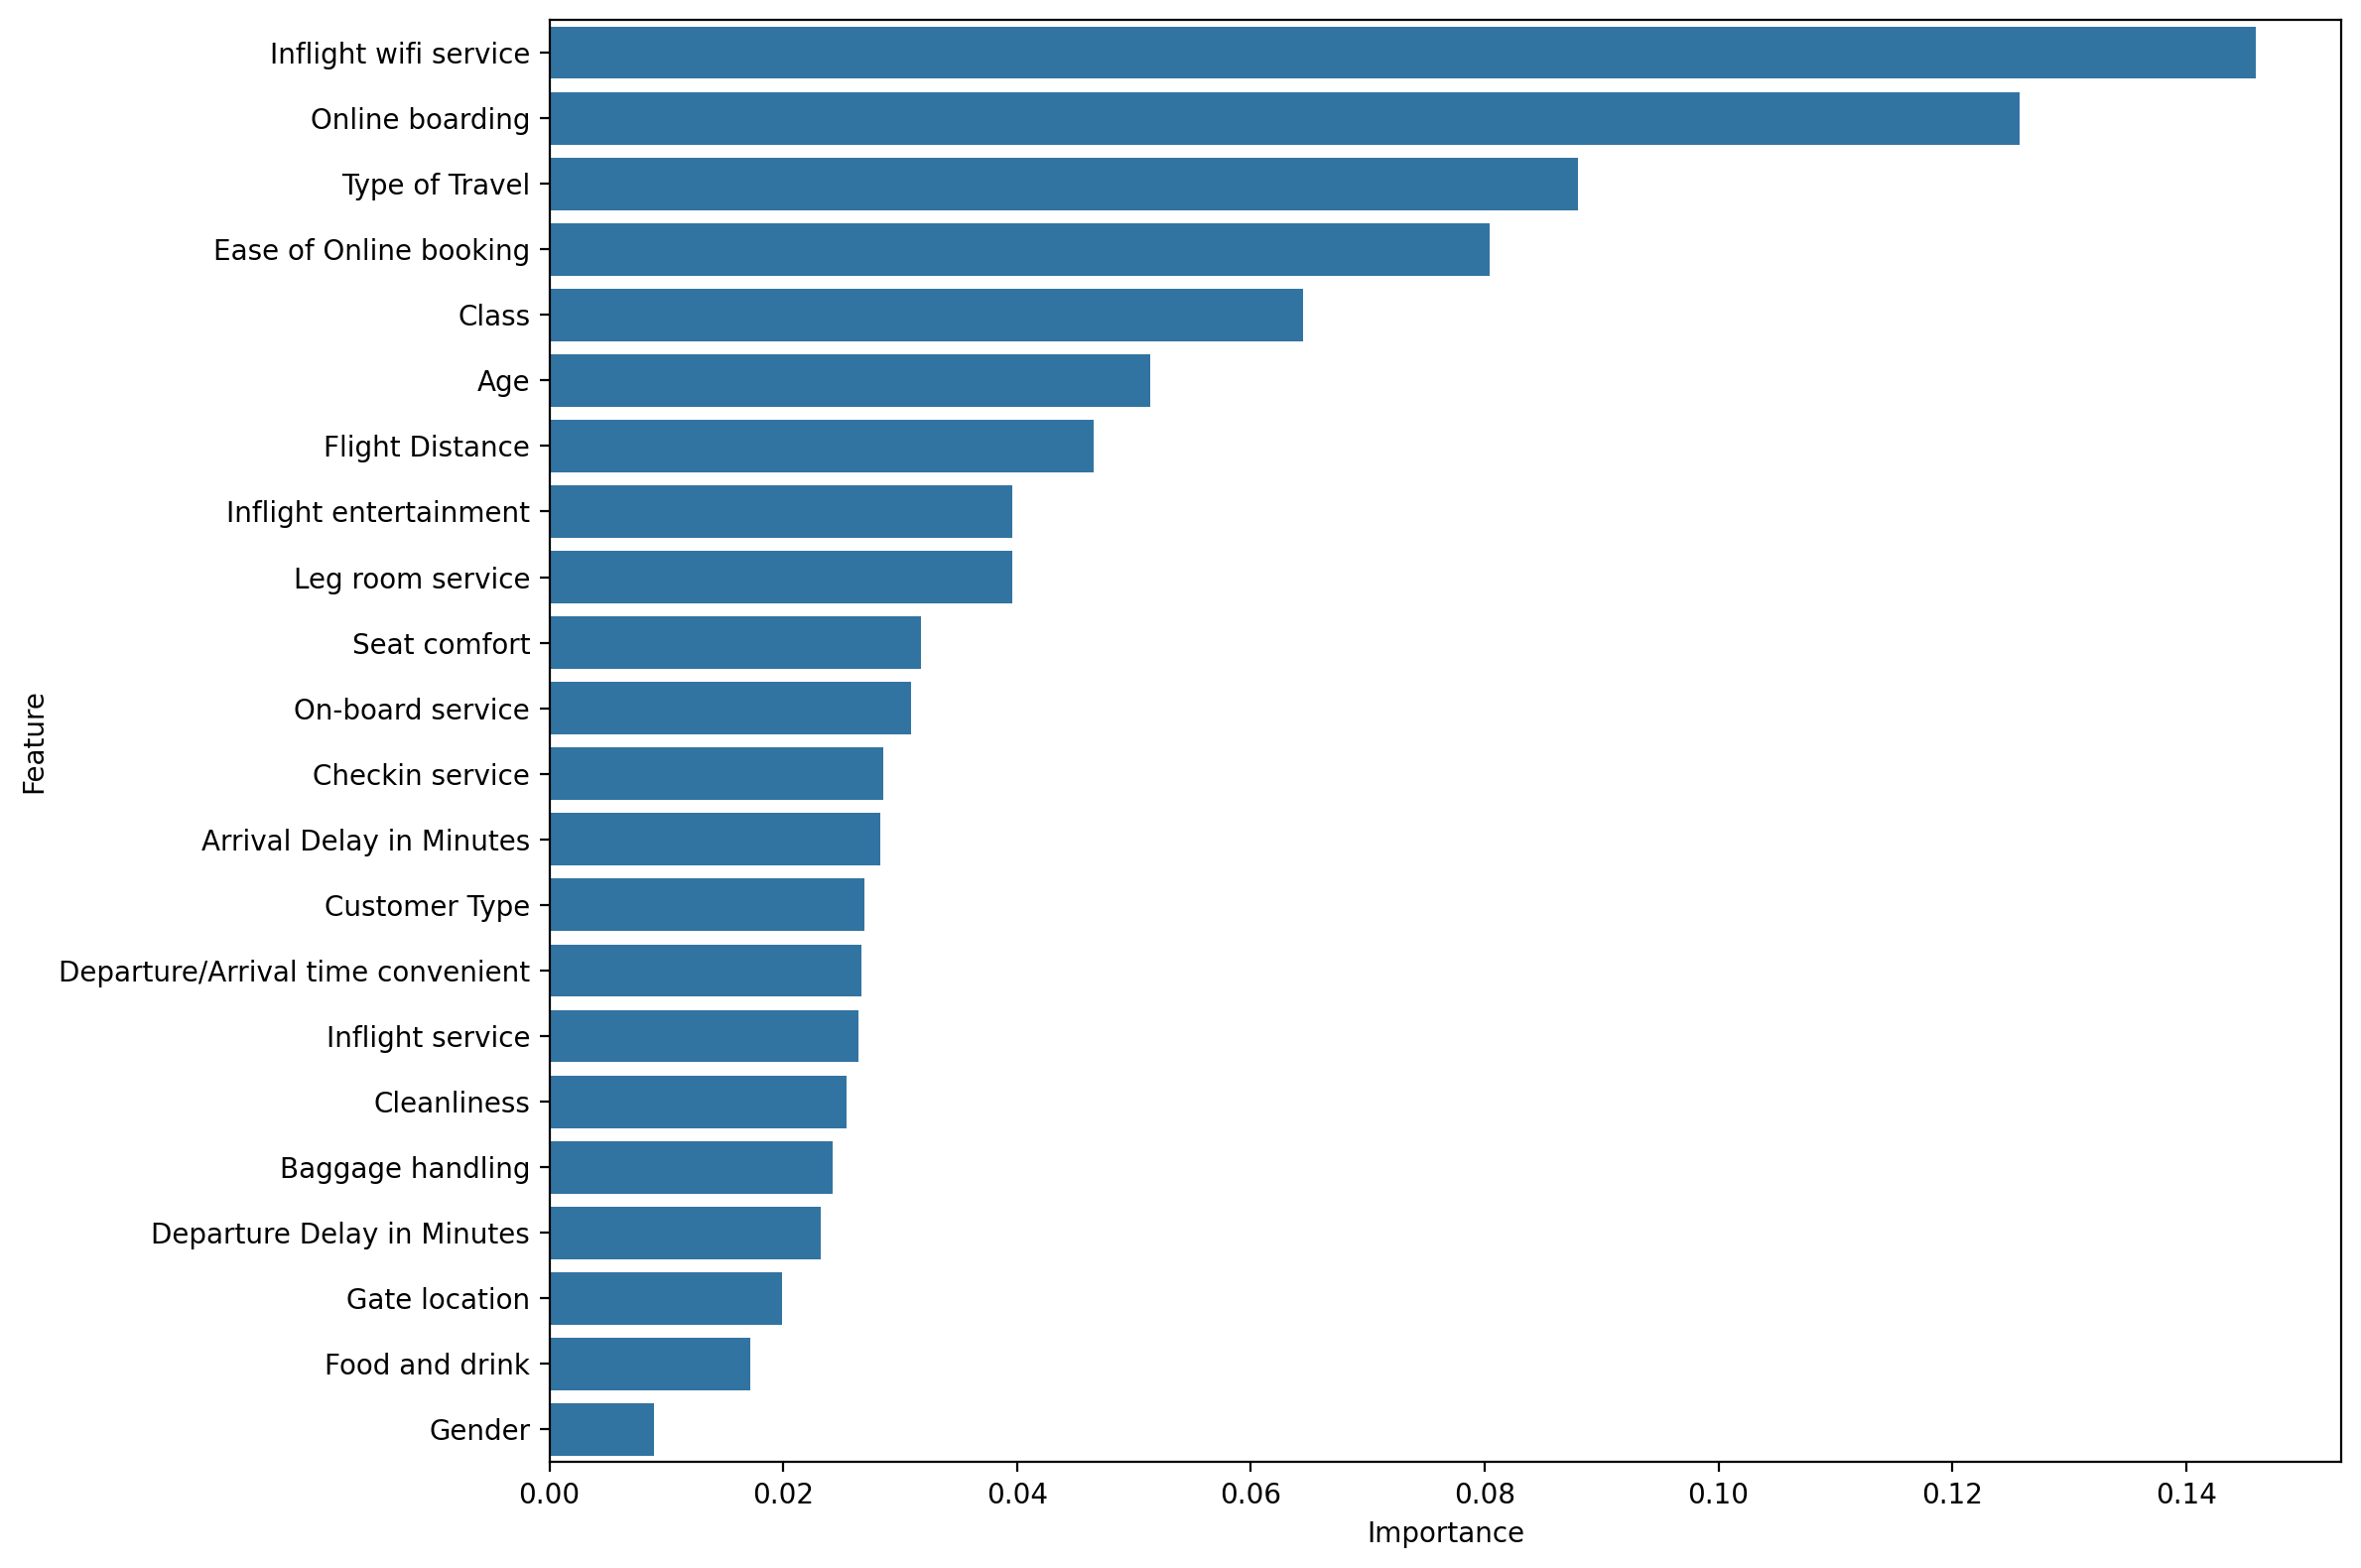

In [134]:
# 변수 중요도 추출
importances = model.feature_importances_
features = x.columns

# 변수 중요도를 데이터프레임
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### (4) 결과 정리

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [135]:
# 가장 중요하다고 확인된 변수 5개
# 1. Inflight wifi service
# 2. Online boarding
# 3. Type of Travel
# 4. Ease of Online booking
# 5. Class

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [136]:
# 가장 중요하지 않다고 확인된 변수 5개
# 1. Gnder
# 2. Food and drink
# 3. Gate location
# 4. Departure Delay in Minutes
# 5. Departure/Arrival time convenient

## **5. 미션 4: 머신러닝 모델링 #2**

- 35세를 기준으로 데이터를 분리해 각각에 대한 모델을 만들어봅니다.

### (1) 데이터 분리

- 더 세분화할 수 있지만, 35세를 기준으로 두 개의 데이터프레임을 만듭니다.
    - **data01**: Age <= 35
    - **data02**: Age > 35

In [137]:
# 데이터 분리
data01 = data.loc[data['Age'] <= 35].copy()
data02 = data.loc[data['Age'] > 35].copy()


print(data01.shape)
print(data02.shape)

(5830, 23)
(13448, 23)


### (2) 35세 이하 모델링

- **data01** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [138]:
# target 변수 선정 및 x, y 분리
target = 'Satisfaction'
x_01 = data01.drop(target, axis=1)
y_01 = data01[target]

# 분리 확인
print(x_01.shape)
print(y_01.shape)

(5830, 22)
(5830,)


- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [139]:
x_train_01, x_val_01, y_train_01, y_val_01 = train_test_split(x_01, y_01, test_size=0.3, random_state=1)

- 모델링을 수행합니다.

In [140]:
# 모델링 수행 (RandomForestClassifier)
model_01 = RandomForestClassifier(random_state=1)
model_01.fit(x_train_01, y_train_01)

# 예측 및 성능 평가
y_pred_01 = model_01.predict(x_val_01)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84       581
           1       0.98      0.99      0.98      5203

    accuracy                           0.97      5784
   macro avg       0.94      0.89      0.91      5784
weighted avg       0.97      0.97      0.97      5784



- 변수 중요도를 확인합니다.

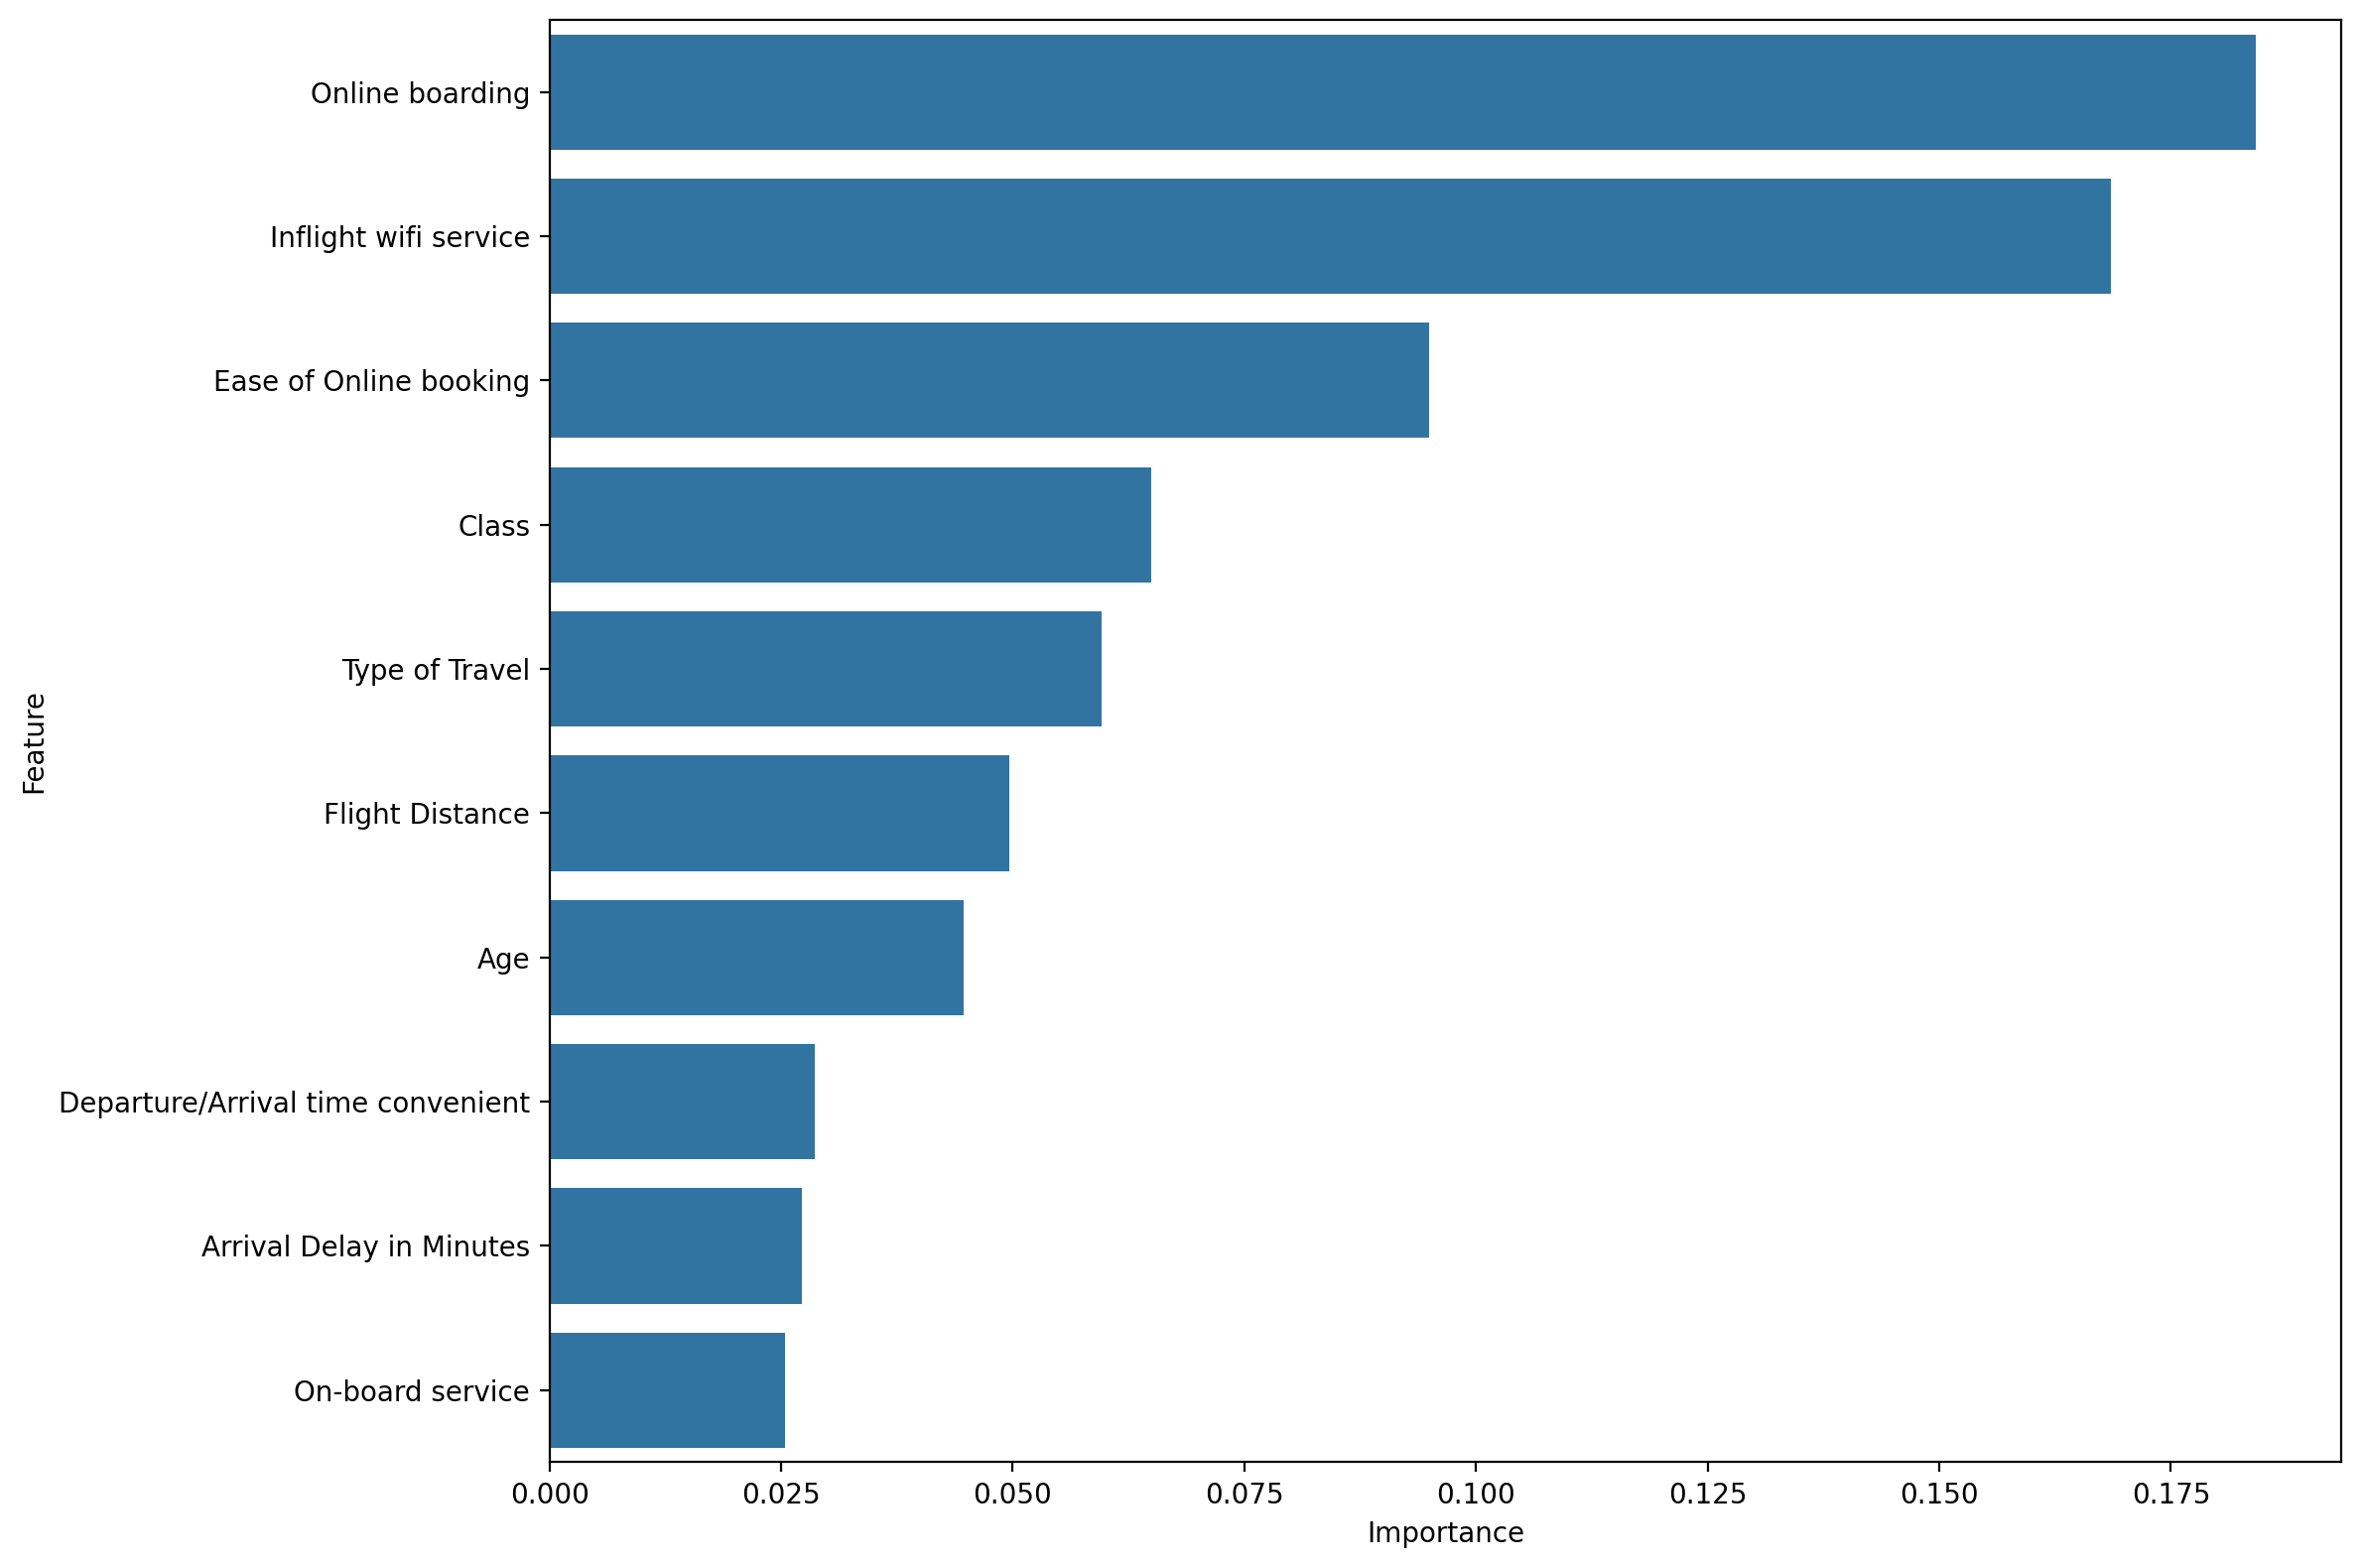

In [141]:
# 변수 중요도 추출 및 시각화
importances_01 = model_01.feature_importances_
features_01 = x_01.columns

feature_importance_df_01 = pd.DataFrame({'Feature': features_01, 'Importance': importances_01})
feature_importance_df_01 = feature_importance_df_01.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_01.head(10))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

- 중요하다고 확인된 변수 5개는 무엇인가요?


In [142]:
# 가장 중요하다고 확인된 변수 5개 (Age <= 35)
# 1. Online boarding
# 2. Inflight wifi service
# 3. Ease of Online booking
# 4. Class
# 5. Type of Travel

- 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [143]:
# 가장 중요하지 않다고 확인된 변수 5개 (Age <= 35)
# 1. Inflight service
# 2. Leg room service
# 3. baggage handling
# 4. Seat comfort
# 5. Gender

### (3) 35세 초과 모델링

- **data02** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [144]:
# target 변수 선정 및 x, y 분리
target = 'Satisfaction'
x_02 = data02.drop(target, axis=1)
y_02 = data02[target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [145]:
x_train_02, x_val_02, y_train_02, y_val_02 = train_test_split(x_02, y_02, test_size=0.3, random_state=1)

- 모델링을 수행합니다.

In [146]:
# 모델링 수행 (RandomForestClassifier)
model_02 = RandomForestClassifier(random_state=1)
model_02.fit(x_train_02, y_train_02)

# 예측 및 성능 평가
y_pred_02 = model_02.predict(x_val_02)

print(classification_report(y_val_02, y_pred_02))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81       321
           1       0.98      0.99      0.99      3714

    accuracy                           0.97      4035
   macro avg       0.94      0.86      0.90      4035
weighted avg       0.97      0.97      0.97      4035



- 변수 중요도를 확인합니다.

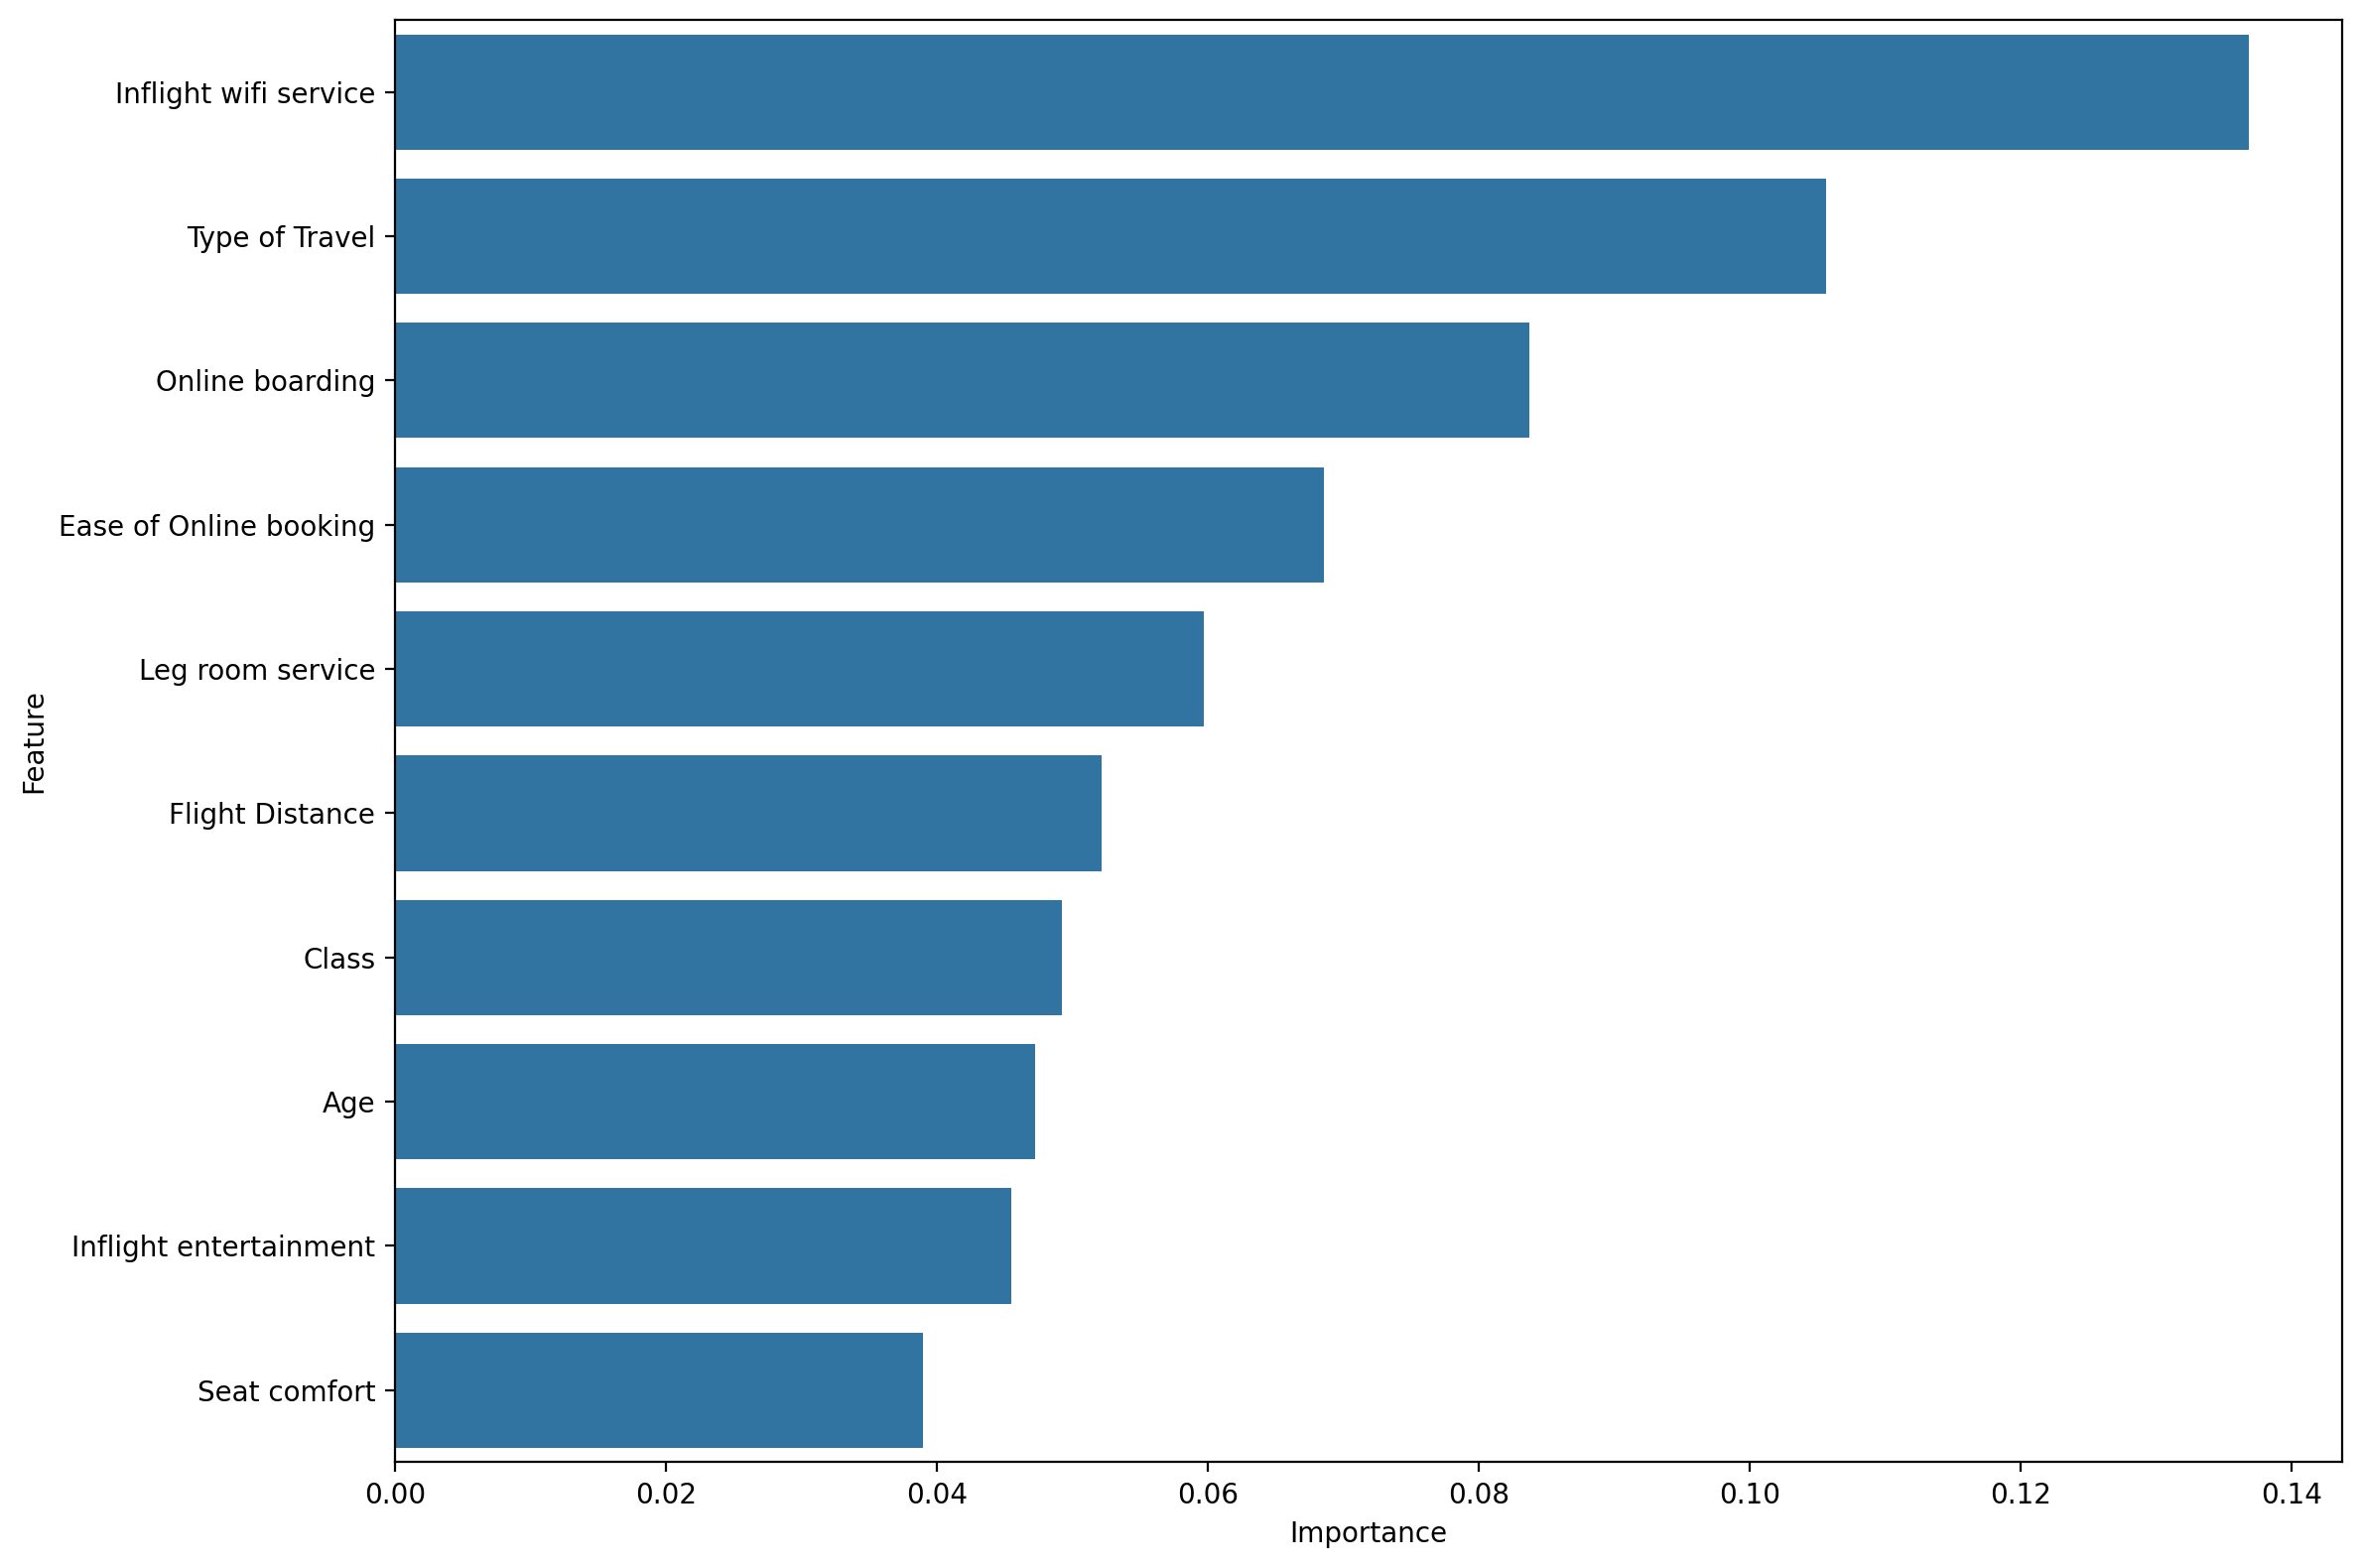

In [147]:
# 변수 중요도 추출 및 시각화
importances_02 = model_02.feature_importances_
features_02 = x_02.columns

feature_importance_df_02 = pd.DataFrame({'Feature': features_02, 'Importance': importances_02})
feature_importance_df_02 = feature_importance_df_02.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_02.head(10))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [148]:
# 가장 중요하다고 확인된 변수 5개 (Age > 35)
# 1. InFlight wifi service
# 2. Type of Travel
# 3. online boarding
# 4. Ease of Online booking
# 5. Leg room service

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [149]:
# 가장 중요하지 않다고 확인된 변수 5개 (Age > 35)
# 1. Baggage handling
# 2. Food and drink
# 3. Customer Type
# 4. Gate location
# 5. Gender

### (4) 의견 정리

- 위 모델링 과정과 변수 중요도 확인 과정 결과에 대한 의견을 정리합니다.

## 변수 중요도 정리

#### 전체 데이터 모델
| 구분 | 중요도 상위 5개 변수 | 중요도 하위 5개 변수 |
|---|---|---|
| **변수** | 1. Inflight wifi service <br> 2. Online boarding <br> 3. Type of Travel <br> 4. Ease of Online booking <br> 5. Class | 1. Gender <br> 2. Food and drink <br> 3. Gate location <br> 4. Departure Delay in Minutes <br> 5. Departure/Arrival time convenient |

#### 35세 이하 (Age <= 35) 모델
| 구분 | 중요도 상위 5개 변수 | 중요도 하위 5개 변수 |
|---|---|---|
| **변수** | 1. Online boarding <br> 2. Inflight wifi service <br> 3. Ease of Online booking <br> 4. Class <br> 5. Type of Travel | 1. Inflight service <br> 2. Leg room service <br> 3. Baggage handling <br> 4. Seat comfort <br> 5. Gender |

#### 35세 이상 (Age > 35) 모델
| 구분 | 중요도 상위 5개 변수 | 중요도 하위 5개 변수 |
|---|---|---|
| **변수** | 1. Inflight wifi service <br> 2. Type of Travel <br> 3. Online boarding <br> 4. Ease of Online booking <br> 5. Leg room service | 1. Baggage handling <br> 2. Food and drink <br> 3. Customer Type <br> 4. Gate location <br> 5. Gender |


In [150]:
# 35 이하 35 초과 비교
'''
35세 이하 그룹과 35세 초과 그룹의 모델링 결과를 비교했을 때,
두 그룹 모두 'Online boarding', 'Inflight wifi service', 'Type of Travel' 등 온라인 서비스 및 비행 유형 관련 변수들이 높은 중요도를 보임
특히 35세 이하 그룹에서는 'Flight Distance'가 중요하게 나타난 반면, 35세 초과 그룹에서는 'Class'와 'Customer Type'이 상대적으로 중요하게 나타나 연령대별 고객 특성에 따른 만족도 요인이 다름.
또한, 두 그룹 모두 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gate location', 'Gender', 'Departure/Arrival time convenient' 변수들은 중요도가 낮게 평가함.
이는 연령대와 관계없이 지연 시간이나 기본적인 편의성보다는 직접적인 기내 서비스와 예약 과정의 만족도가 고객 만족에 더 큰 영향을 미친다고 보임.
따라서 서비스 개선 시에는 고객의 연령대를 고려한 맞춤형 전략 수립이 필요하며, 특히 온라인 서비스 품질 향상에 집중하는 것이 효과적일 것이라고 생각.
'''

"\n35세 이하 그룹과 35세 초과 그룹의 모델링 결과를 비교했을 때,\n두 그룹 모두 'Online boarding', 'Inflight wifi service', 'Type of Travel' 등 온라인 서비스 및 비행 유형 관련 변수들이 높은 중요도를 보임\n특히 35세 이하 그룹에서는 'Flight Distance'가 중요하게 나타난 반면, 35세 초과 그룹에서는 'Class'와 'Customer Type'이 상대적으로 중요하게 나타나 연령대별 고객 특성에 따른 만족도 요인이 다름.\n또한, 두 그룹 모두 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gate location', 'Gender', 'Departure/Arrival time convenient' 변수들은 중요도가 낮게 평가함.\n이는 연령대와 관계없이 지연 시간이나 기본적인 편의성보다는 직접적인 기내 서비스와 예약 과정의 만족도가 고객 만족에 더 큰 영향을 미친다고 보임.\n따라서 서비스 개선 시에는 고객의 연령대를 고려한 맞춤형 전략 수립이 필요하며, 특히 온라인 서비스 품질 향상에 집중하는 것이 효과적일 것이라고 생각.\n"

## **6. 미션 5: 데이터 분석**

- 위에서 확인된 변수 중요도를 기준으로 분석할 변수를 5개 선정하고 분석을 수행합니다.
- **data** 데이터프레임을 대상으로 분석합니다.
- Satisfaction 변수와의 **이변량 분석**에 중점을 두고 수행합니다.
- 각 분석 결과에 대한 의견을 주석으로 정리합니다.

### (1) 변수 중요도를 기준으로 선택된 변수 분석 및 통계 검정

미션 3에서 확인된 변수 중요도를 바탕으로 다음 5개 변수를 선택하여 `Satisfaction` 변수와의 이변량 분석 및 통계 검정을 수행합니다.


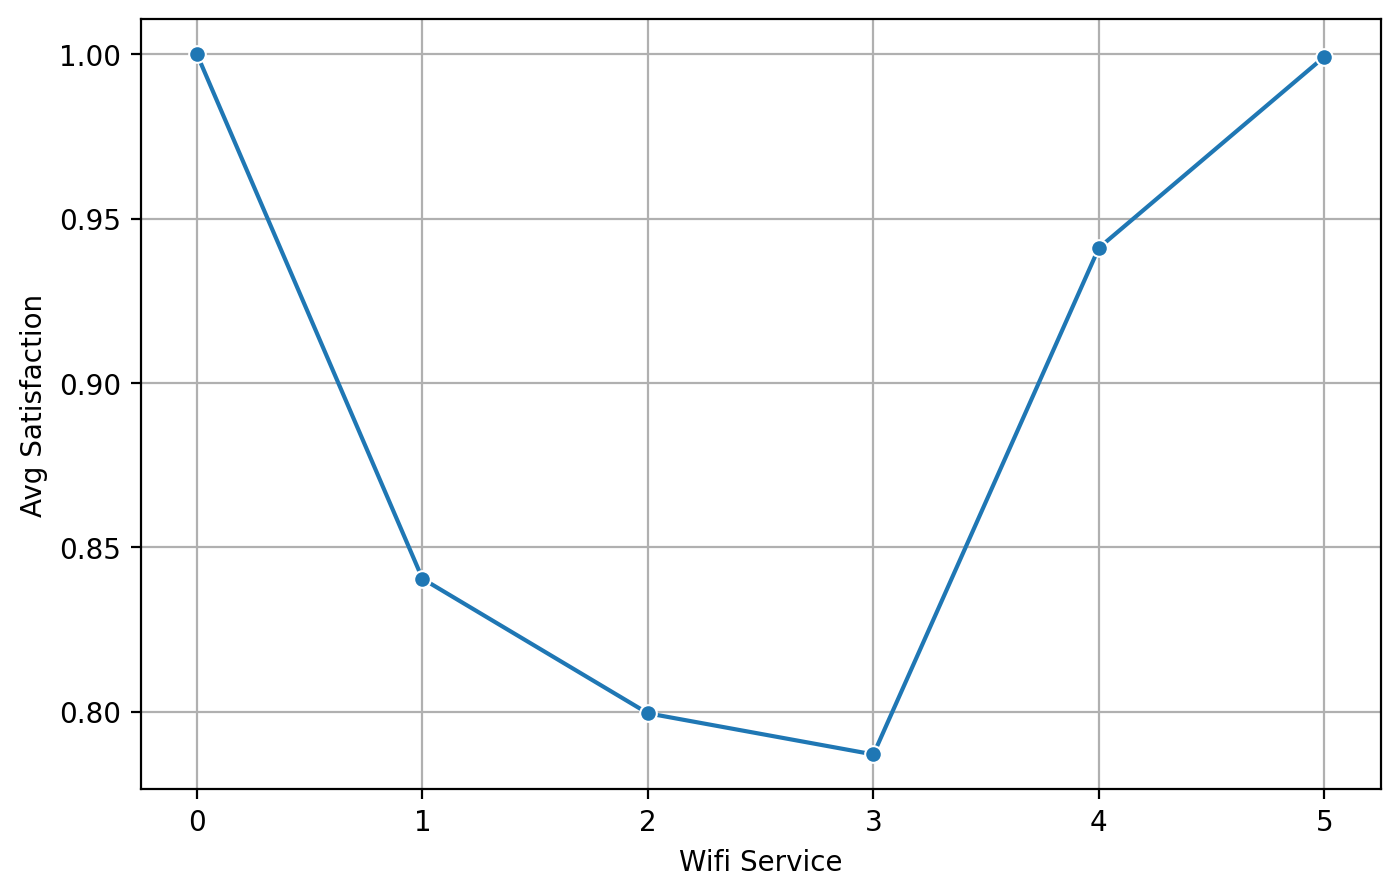

In [151]:
# Inflight wifi service vs Satisfaction (시각화)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr
import statsmodels.api as sm
from statsmodels.genmod import families

mean_satisfaction_wifi = data.groupby('Inflight wifi service')['Satisfaction'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(x='Inflight wifi service', y='Satisfaction', data=mean_satisfaction_wifi, marker='o')
plt.xlabel('Wifi Service')
plt.ylabel('Avg Satisfaction')
plt.xticks(range(6))
plt.grid(True)
plt.show()

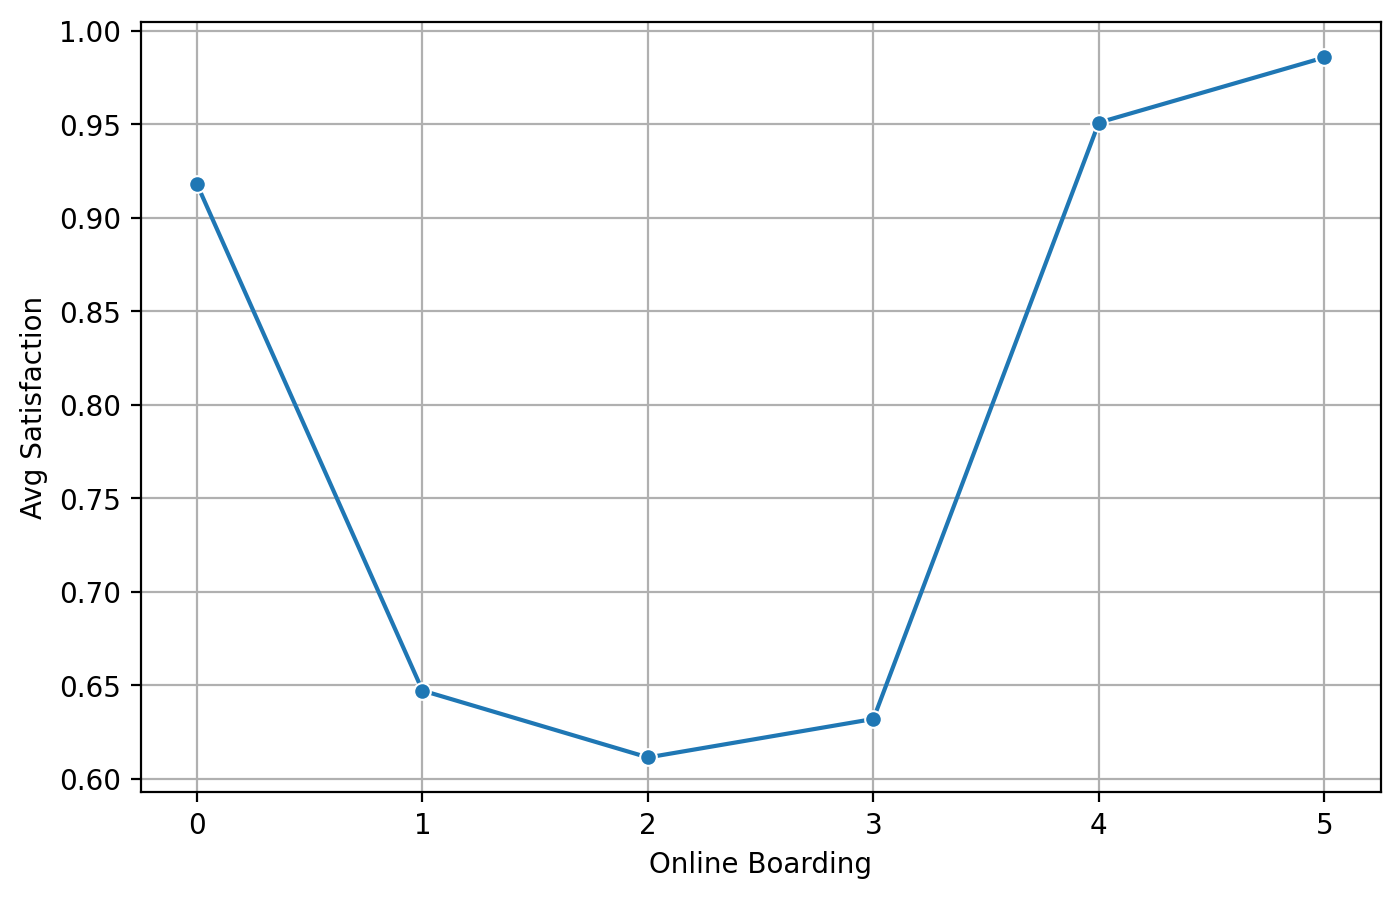

In [152]:
# Online boarding vs Satisfaction (시각화)
mean_satisfaction_boarding = data.groupby('Online boarding')['Satisfaction'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(x='Online boarding', y='Satisfaction', data=mean_satisfaction_boarding, marker='o')
plt.xlabel('Online Boarding')
plt.ylabel('Avg Satisfaction')
plt.xticks(range(6))
plt.grid(True)
plt.show()

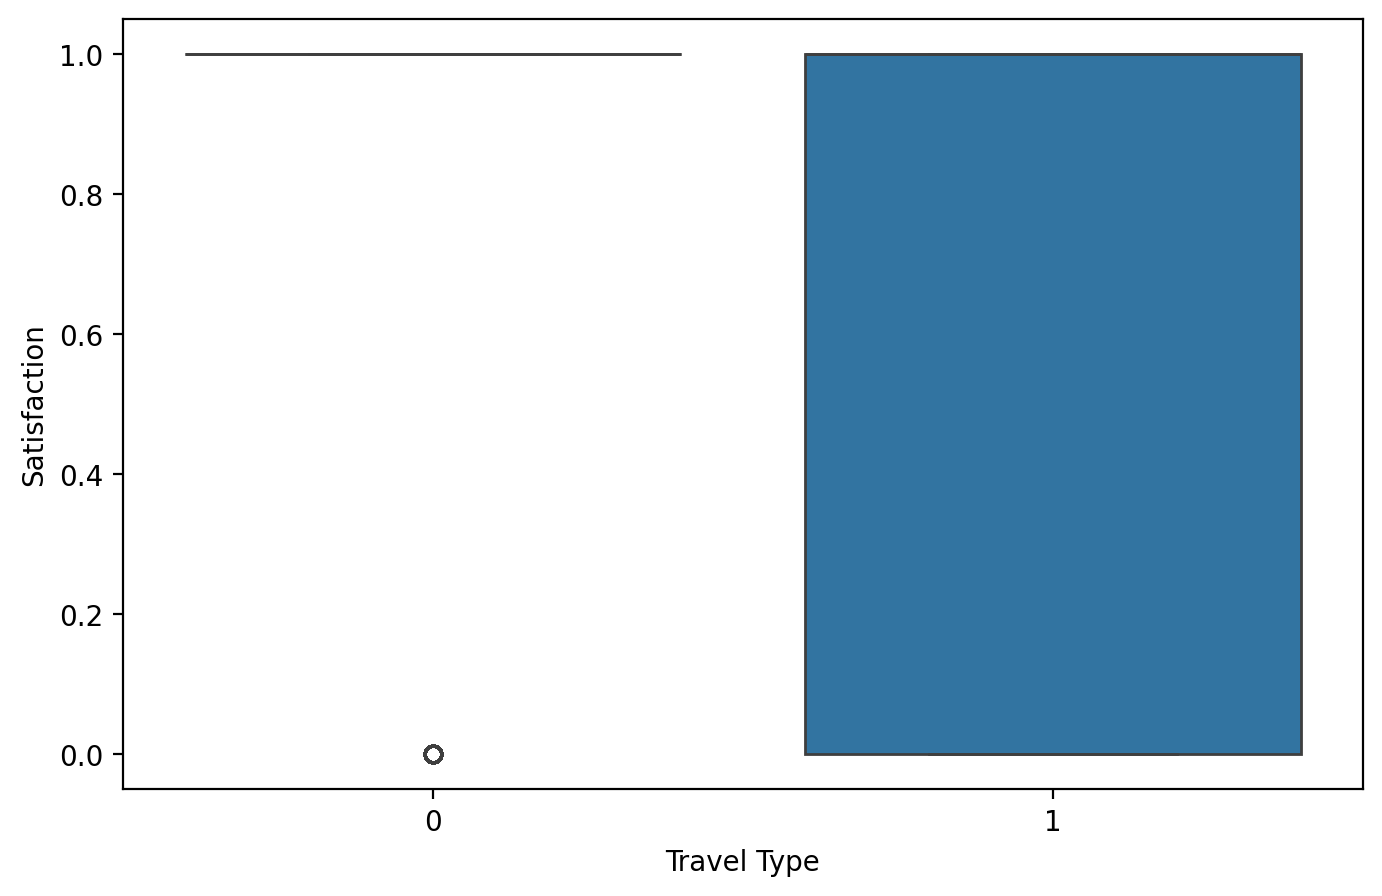

In [153]:
# Type of Travel vs Satisfaction (시각화)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Type of Travel', y='Satisfaction', data=data)
plt.xlabel('Travel Type')
plt.ylabel('Satisfaction')
plt.show()

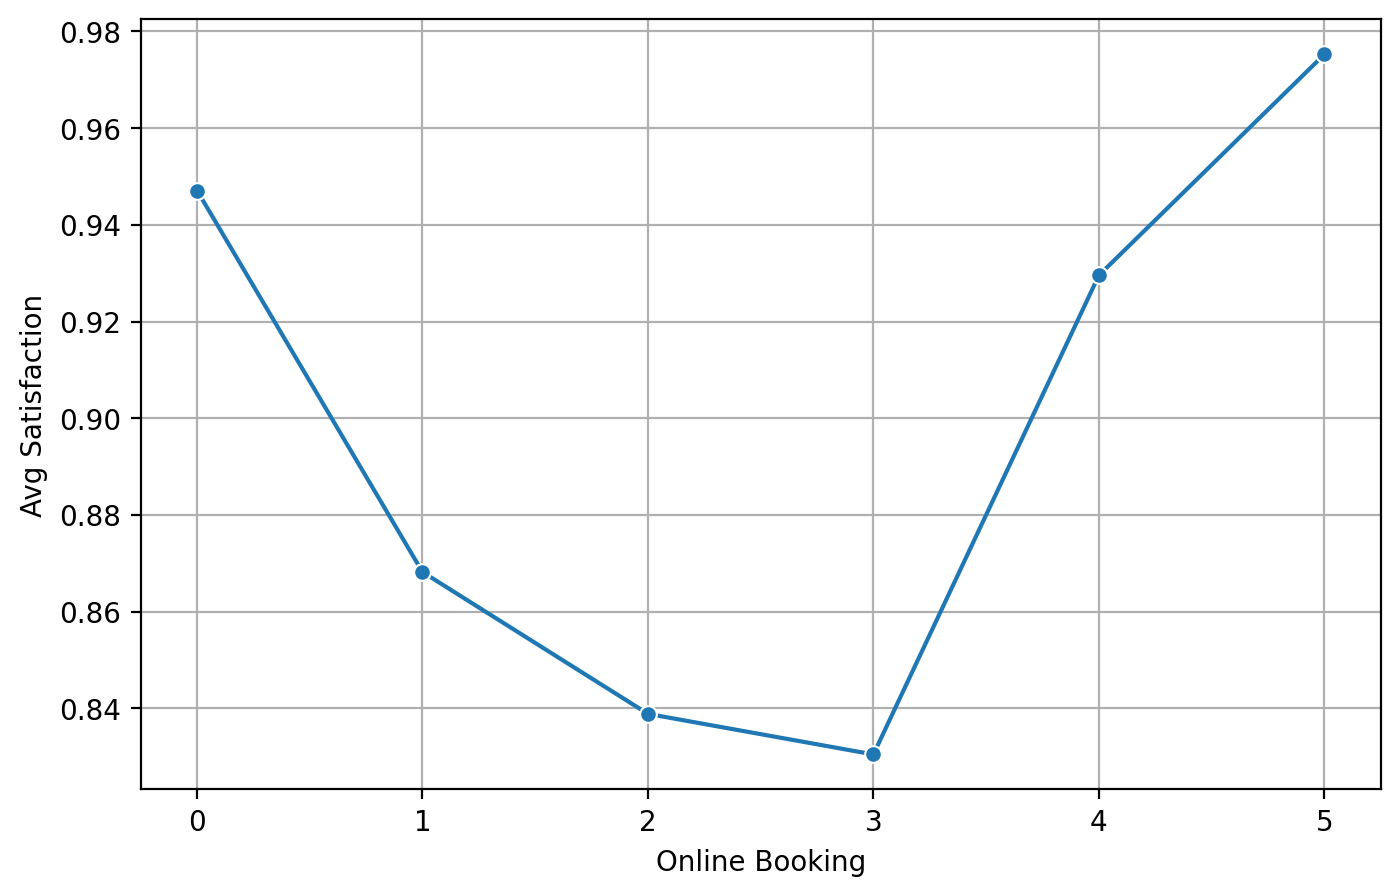

In [154]:
# Ease of Online booking vs Satisfaction (시각화)
mean_satisfaction_booking = data.groupby('Ease of Online booking')['Satisfaction'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(x='Ease of Online booking', y='Satisfaction', data=mean_satisfaction_booking, marker='o')
plt.xlabel('Online Booking')
plt.ylabel('Avg Satisfaction')
plt.xticks(range(6))
plt.grid(True)
plt.show()

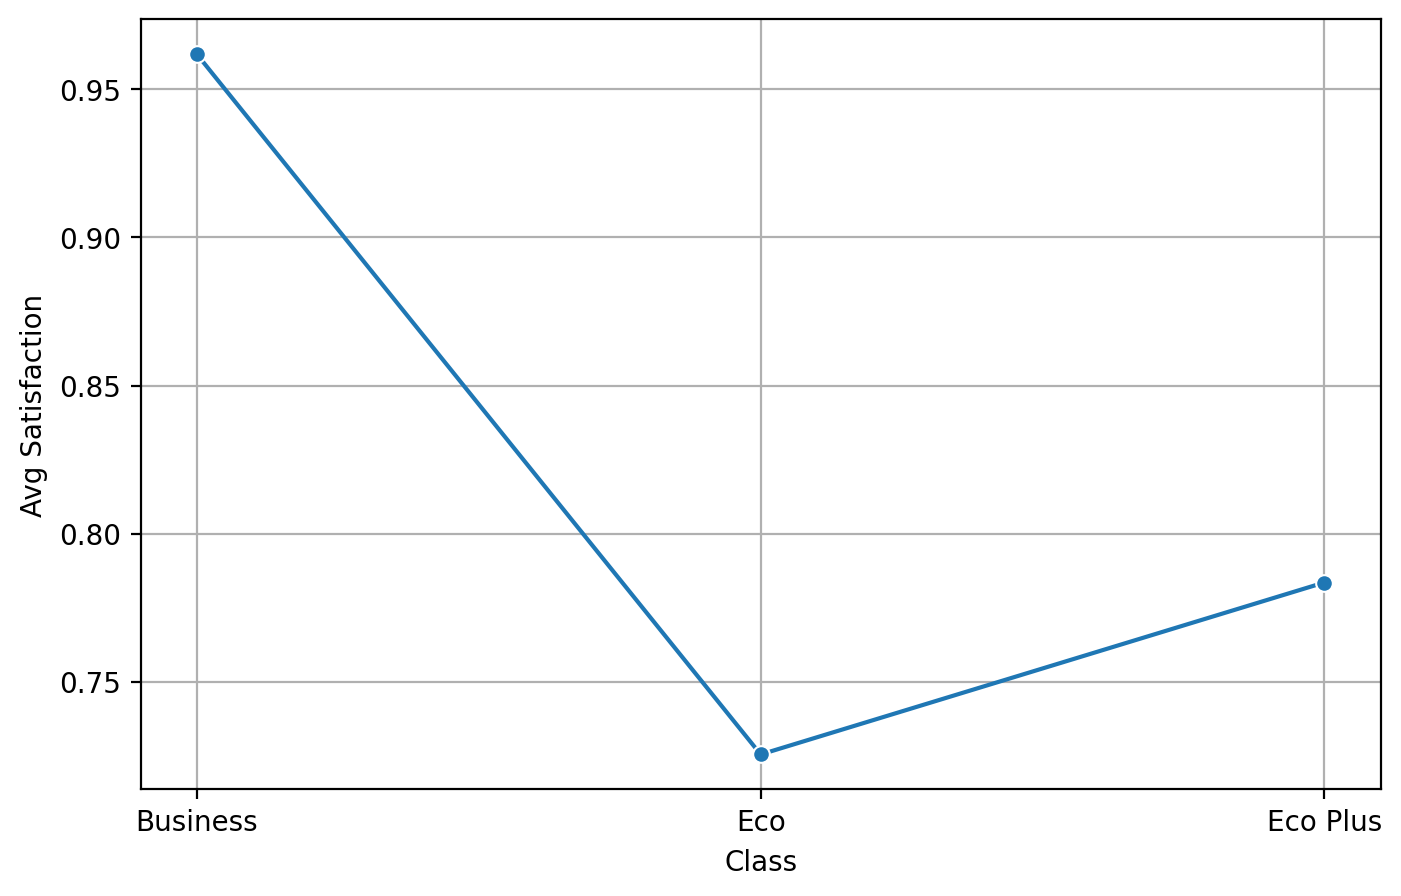

In [155]:
# Class vs Satisfaction (시각화)
mean_satisfaction_class = data.groupby('Class')['Satisfaction'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(x='Class', y='Satisfaction', data=mean_satisfaction_class, marker='o')
plt.xlabel('Class')
plt.ylabel('Avg Satisfaction')
plt.xticks(ticks=[0, 1, 2], labels=['Business', 'Eco', 'Eco Plus'])
plt.grid(True)
plt.show()

### (2) 종합 의견

고객 만족도에 가장 큰 영향을 미치는 요인들은 주로 **온라인 서비스(기내 와이파이, 온라인 탑승 수속, 온라인 예약 편리성)와 비행 유형 및 좌석 등급**으로 나타났습니다. 통계적 검정(카이제곱 검정, 상관분석, t-test, 로지스틱 회귀분석) 결과 모든 선정된 변수들이 고객 만족도와 통계적으로 유의미한 관계를 가지고 있음을 확인했습니다. 특히 온라인 서비스 만족도가 높을수록 고객 만족도 또한 현저히 증가하는 경향을 보였으며, 비즈니스 여행객과 비즈니스 클래스 이용객의 만족도가 다른 그룹에 비해 월등히 높았습니다. 이는 고객의 만족도를 높이기 위해서는 온라인 플랫폼의 사용 편의성과 효율성을 개선하고, 비즈니스 고객층을 위한 맞춤형 서비스 강화가 중요함을 시사합니다. 반면, 미션 4에서 확인된 중요도가 낮은 변수들(예: 지연 시간, 성별 등)은 만족도에 미치는 영향이 상대적으로 적다고 볼 수 있습니다.

## **7. 저장하기**

- **to_csv()** 메서드를 사용해 이후 과정을 위해 data 데이터프레임을 **project01** 폴더에 저장합니다.
    - index=False 옵션 지정
    - data → path + 'data.csv'
    
- 저장된 파일을 필히 확인합니다.

In [156]:
# 파일 저장
data.to_csv(path + 'data.csv', index=False)